# CerviTrust - Pipeline federe de depistage cervical (notebook Kaggle, avec visualisation)

**Version modifiee** de `notebooke6a839135f (1).ipynb` : chaque etape est desormais
**executee** (plus de lignes `# Decommenter pour executer...` laissees commentees) et suivie
d'une **cellule de visualisation** (courbes, images, tableaux). Le detail complet de ce qui a
change par rapport a la version precedente est dans `CHANGELOG.md` (fourni a cote de ce fichier).

**Pourquoi la version precedente n'affichait rien.** Toutes les fonctions (segmentation,
entrainement, federation, MIL, explicabilite, agent) etaient bien definies et s'importaient
sans erreur - c'est pour ca que "tout tournait sans erreur". Mais l'execution reelle de chaque
etape etait systematiquement laissee en commentaire, par exemple :
```python
# Decommenter pour executer (necessite les 3 datasets ajoutes + GPU) :
# segmentor = build_segmentor(CONFIG)
# run_on_site("cx22", Path(CONFIG["paths"]["cx22_images"]), CONFIG, segmentor)
```
Une fonction definie mais jamais appelee ne peut rien afficher ni rien calculer. Ce notebook
decommente ces appels et ajoute, apres chacun, une cellule qui affiche concretement le resultat
(image, courbe, tableau) pour que chaque etape soit verifiable a l'oeil avant de passer a la
suivante.

**Ordre d'execution.** Lancez les cellules dans l'ordre. La cellule d'installation doit etre
suivie d'un redemarrage du kernel (indique explicitement) avant de continuer.


## 0. Installation des dependances

**Ce qui a change ici (voir CHANGELOG.md, section "Corrections d'environnement") :** dans la
version precedente, `numpy` etait installe/desinstalle plusieurs fois de suite (2.0.2 puis a
nouveau force en 2.2.6 tout en bas de la meme cellule). Comme Python garde en memoire le module
`numpy` des le premier `import`, ce dernier `pip install` ne changeait rien tant que le kernel
n'etait pas redemarre - source de confusion. Ici, `numpy` n'est installe **qu'une seule fois**,
dans sa version finale, et un redemarrage de kernel est explicitement demande juste apres.


In [1]:
# Installation des dependances absentes de l'image Kaggle de base.
# numpy==2.2.6 est la version qui satisfait a la fois tiatoolbox (>=2.0.0,<=2.4.6),
# opencv-python (>=2,<2.3.0 selon la variante) et le scipy installe par defaut sur Kaggle.

!pip install -q laplace-torch==0.2.1
!pip install -q grad-cam==1.5.4 timm==1.0.7 bitsandbytes
!pip install -q "tiatoolbox>=2.0"
!pip install -q --no-deps flwr==1.9.0
!pip uninstall -y -q tensorflow
!pip install --no-cache-dir --force-reinstall -q "numpy==2.2.6"

print("Installation terminee.")
print("IMPORTANT : redemarrez le kernel maintenant (Run -> Restart Session), puis reprenez")
print("a la cellule suivante. Ne relancez pas cette cellule d'installation apres redemarrage.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 1.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.7/89.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.6/196.6 kB 2.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 7.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 22.3 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.5/47.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 26.4 MB/s eta 0:00:0000:01m00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 777.2 kB/s eta 0:00:00 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━

### Apres redemarrage du kernel : verification de l'environnement

`flwr==1.9.0` a ete ecrit avant numpy 2.0 et utilise en interne l'alias `np.float_`, supprime
depuis. Le correctif ci-dessous re-cree cet alias (et deux autres du meme type) avant tout
`import flwr` - voir CHANGELOG.md pour le detail de pourquoi ce patch est necessaire et sans
danger (ce sont de simples renommages vers les types modernes, pas un changement de comportement).


In [ ]:
!pip uninstall -y numpy scipy
!pip install -q numpy==1.26.4 scipy==1.13.1

import os
os._exit(0)

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: scipy 1.13.1
Uninstalling scipy-1.13.1:
  Successfully uninstalled scipy-1.13.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
flwr 1.9.0 requires iterators<0.0.3,>=0.0.2, which is not installed.
flwr 1.9.0 requires tomli<3.0.0,>=2.0.1, which is not installed.
dopamine-rl 4.1.2 requires tensorflow>=2.2.0, which is not installed.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
imagecodecs 2026.6.6 requires numpy>=2.1, but you have numpy 1.26.4 which is incompatible.
flwr 1.9.0 requires cryptography<43.0.0,>=42.0.4, but you have cryptography 43.0.3 which is 

In [ ]:
!pip uninstall -y flwr iterators protobuf cryptography pathspec typer tomli > /dev/null 2>&1

!pip install -q \
    flwr==1.9.0 \
    iterators==0.0.2 \
    tomli==2.0.1 \
    cryptography==42.0.8 \
    protobuf==4.25.3 \
    pathspec==0.12.1 \
    "typer[all]==0.9.0"

import os
os._exit(0)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 12.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.9/45.9 kB 3.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
grpcio-tools 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.3 which is incompatible.
rfc3161-client 1.0.6 requires cryptography>=43, but you have cryptography 42.0.8 which is incompatible.
black 26.5.1 requires pathspec>=1.0.0, but you have pathspec 0.12.1 which is incompatible.
google-cloud-vision 3.15.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 4.25.3 whi

In [1]:
import flwr as fl
print(fl.__version__)

1.9.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [2]:
%matplotlib inline
import numpy as np

if not hasattr(np, "float_"):
    np.float_ = np.float64
if not hasattr(np, "complex_"):
    np.complex_ = np.complex128
if not hasattr(np, "unicode_"):
    np.unicode_ = np.str_

from tiatoolbox.models.engine.nucleus_instance_segmentor import NucleusInstanceSegmentor
import flwr as fl
from flwr.common import ndarrays_to_parameters, parameters_to_ndarrays

print("numpy    :", np.__version__)
print("flwr     :", fl.__version__)
print("tiatoolbox: import OK")

_arr = [np.random.rand(3, 3).astype(np.float32)]
_back = parameters_to_ndarrays(ndarrays_to_parameters(_arr))
print("Conversion NDArrays (flwr <-> numpy) OK :", np.allclose(_arr[0], _back[0]))


|2026-07-18|14:34:52.879| [WARNING] /usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



|2026-07-18|14:34:52.879| [INFO] NumExpr defaulting to 4 threads.


|2026-07-18|14:35:20.281| [WARNING] /usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

IOStream.flush timed out
|2026-07-18|14:35:10.281| [WARNING] /usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

|2026-07-18|14:35:10.280| [WARNING] /usr/local/lib/python3.12/dist-packages/defusedxml/__init__.py:30: DeprecationWarning: defusedxml.cElementTree is deprecated, import from defusedxml.ElementTree instead.
  from . import cElementTree

IOStream.flush timed ou

numpy    : 1.26.4
flwr     : 1.9.0
tiatoolbox: import OK
Conversion NDArrays (flwr <-> numpy) OK : True


## 1. Configuration + decouverte des chemins Kaggle

**Pourquoi une cellule de decouverte avant tout le reste.** Les archives Kaggle ne sont pas
toujours imbriquees exactement comme l'originale. Plutot que de deviner une profondeur fixe,
on liste explicitement ce qui est present sous `/kaggle/input` : si les chemins de `CONFIG`
ne correspondent pas a ce qu'affiche cette cellule, ajustez les 3 chemins racine.

**La correspondance de classes** (le point le plus important de cette adaptation) - ni SIPaKMeD
ni Herlev n'utilisent les 4 classes Bethesda (NILM/LSIL/HSIL/SCC) du pipeline ; le mapping complet
est documente dans `CONFIG["paths"]["sites"][i]["class_folder_map"]` ci-dessous et dans
`CHANGELOG.md`.


In [3]:
import os
from pathlib import Path

KAGGLE_INPUT = Path("/kaggle/input/datasets/")

def list_kaggle_input(max_depth: int = 3):
    """Affiche l'arborescence de /kaggle/input jusqu'a max_depth niveaux."""
    if not KAGGLE_INPUT.exists():
        print("/kaggle/input introuvable - ce notebook est concu pour tourner sur Kaggle.")
        return
    for dataset_dir in sorted(KAGGLE_INPUT.iterdir()):
        print(f"\n{dataset_dir}")
        for path in sorted(dataset_dir.rglob("*")):
            depth = len(path.relative_to(dataset_dir).parts)
            if depth <= max_depth and path.is_dir():
                print("  " * depth + path.name + "/")

list_kaggle_input()



/kaggle/input/datasets/niladrishekharray
  cx22-multi-train/
    Cx22_Multi_Train/
      Pair/
      Test/
      Train/

/kaggle/input/datasets/prahladmehandiratta
  cervical-cancer-largest-dataset-sipakmed/
    im_Dyskeratotic/
      im_Dyskeratotic/
    im_Koilocytotic/
      im_Koilocytotic/
    im_Metaplastic/
      im_Metaplastic/
    im_Parabasal/
      im_Parabasal/
    im_Superficial-Intermediate/
      im_Superficial-Intermediate/

/kaggle/input/datasets/yuvrajsinhachowdhury
  herlev-dataset/
    Herlev Dataset/
      test/
      train/


In [113]:
CONFIG = {
    "paths": {
        "sites": [
            {
                "name": "sipakmed",
                "images": "/kaggle/input/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed",
                "class_folder_map": {
                    "im_dyskeratotic": "HSIL",
                    "im_koilocytotic": "LSIL",
                    "im_metaplastic": "NILM",
                    "im_parabasal": "NILM",
                    "im_superficial-intermediate": "NILM",
                },
            },
            {
                "name": "herlev",
                "images": "/kaggle/input/datasets/yuvrajsinhachowdhury/herlev-dataset",
                "class_folder_map": {
                    "normal_columnar": "NILM",
                    "normal_intermediate": "NILM",
                    "normal_superficial": "NILM",
                    "light_dysplastic": "LSIL",
                    "moderate_dysplastic": "HSIL",
                    "severe_dysplastic": "HSIL",
                    "carcinoma_in_situ": "SCC",  # approximation, voir CHANGELOG.md
                },
            },
        ],
        "cx22_images": "/kaggle/input/datasets/niladrishekharray/cx22-multi-train",
        "outputs_root": "/kaggle/working/outputs",
    },
    "classes": {"names": ["NILM", "LSIL", "HSIL", "SCC"]},
    "step_a_segmentation": {
        "model": "hovernet_fast-pannuke",
        "patch_size": 64,
        "batch_size": 16,
        "num_workers": 2,
        "min_nucleus_area": 20,
        "max_images": 20,  # limite le temps GPU passe sur Cx22 pour la demo
    },
    "step_b_classification": {
        "backbone": "efficientnet_b0",
        "pretrained": True,
        "num_classes": 4,
        "image_size": 64,
        "batch_size": 64,
        "epochs": 15,
        "lr": 3.0e-4,
        "weight_decay": 1.0e-4,
        "laplace": {"subset_of_weights": "last_layer", "hessian_structure": "diag", "prior_precision": 1.0},
    },
    "step_c_federated": {"num_clients": 2, "num_rounds": 10, "local_epochs": 1, "strategy": "online_laplace"},
    "step_d_mil": {
        "model": "attention_mil", "hidden_dim": 128, "attention_dim": 64,
        "dropout": 0.25, "epochs": 20, "lr": 1.0e-4, "bag_max_instances": 500,
    },
    "step_e_explainability": {"gradcam_target_layer": "blocks.2", "top_k_cells": 12, "save_overlays": True},
    "step_f_agent": {
        "llm_model": "meta-llama/Meta-Llama-3.1-8B-Instruct",
        "triage_thresholds": {"urgent": 0.85, "review": 0.5},
    },
}

Path(CONFIG["paths"]["outputs_root"]).mkdir(parents=True, exist_ok=True)
print("CONFIG pret. Sorties ecrites sous:", CONFIG["paths"]["outputs_root"])


CONFIG pret. Sorties ecrites sous: /kaggle/working/outputs


## 2. Etape A - Segmentation cellulaire (HoVer-Net pretrained, sur Cx22)

Cx22 fournit les images "lame complete" ; SIPaKMeD/Herlev ne fournissent que des crops de
cellules deja individualisees (voir CHANGELOG.md pour le detail du partage des roles entre
datasets). `run_on_site` est appelee une seule fois, avec `site_name="cx22"`.


In [24]:
import cv2
import numpy as np
import pandas as pd
from tiatoolbox.models.engine.nucleus_instance_segmentor import NucleusInstanceSegmentor


def build_segmentor(cfg: dict) -> NucleusInstanceSegmentor:
    seg_cfg = cfg["step_a_segmentation"]

    return NucleusInstanceSegmentor(
        model=seg_cfg["model"],
        batch_size=seg_cfg["batch_size"],
        num_workers=seg_cfg.get("num_workers", 0),
        device="cuda" if torch.cuda.is_available() else "cpu"
    )


def crop_nucleus(image: np.ndarray, centroid: tuple, patch_size: int) -> np.ndarray:
    """Crop carre centre sur le noyau, avec padding par reflexion si on deborde du bord."""
    h, w = image.shape[:2]
    half = patch_size // 2
    cx, cy = int(round(centroid[0])), int(round(centroid[1]))
    x0, x1 = cx - half, cx + half
    y0, y1 = cy - half, cy + half

    pad_left, pad_top = max(0, -x0), max(0, -y0)
    pad_right, pad_bottom = max(0, x1 - w), max(0, y1 - h)
    x0c, x1c, y0c, y1c = max(0, x0), min(w, x1), max(0, y0), min(h, y1)
    crop = image[y0c:y1c, x0c:x1c]

    if any([pad_left, pad_top, pad_right, pad_bottom]):
        crop = cv2.copyMakeBorder(crop, pad_top, pad_bottom, pad_left, pad_right, borderType=cv2.BORDER_REFLECT_101)
    return crop
def run_on_site(site_name: str, images_dir: Path, cfg: dict, segmentor: NucleusInstanceSegmentor) -> pd.DataFrame:
    seg_cfg = cfg["step_a_segmentation"]
    patch_size, min_area, max_images = seg_cfg["patch_size"], seg_cfg["min_nucleus_area"], seg_cfg.get("max_images")

    out_root = Path(cfg["paths"]["outputs_root"]) / "step_a" / site_name
    crops_dir, masks_dir = out_root / "nucleus_crops", out_root / "instance_masks"
    crops_dir.mkdir(parents=True, exist_ok=True)
    masks_dir.mkdir(parents=True, exist_ok=True)

    image_paths = sorted([
        p for p in images_dir.rglob("*")
        if p.suffix.lower() in (".png", ".jpg", ".jpeg", ".tif", ".tiff") and "mask" not in p.stem.lower()
    ])
    if max_images:
        image_paths = image_paths[:max_images]
    if not image_paths:
        raise FileNotFoundError(f"Aucune image trouvee dans {images_dir}")

    # --- Etape A.1 : segmentation, une image a la fois ---
    results, valid_image_paths = [], []
    for p in image_paths:
        try:
            result = segmentor.run(
                images=[str(p)],
                save_dir=str(out_root / "_tiatoolbox_raw" / p.stem),
                patch_mode=False,
                input_resolutions=[{"units": "baseline", "resolution": 1.0}],
                auto_get_mask=False,
                overwrite=True,
            )
            results.append(result[p])              # <-- CHANGEMENT : result[p], pas result[str(p)]
            valid_image_paths.append(p)
        except ValueError as e:
            print(f"[cx22] {p.name} ignoree (probablement 0 noyau detecte) : {e}")

    image_paths = valid_image_paths

    # --- Etape A.2 : lecture des resultats + crops ---
    records = []
    for image_path, zarr_path in zip(image_paths, results):    # <-- CHANGEMENT : zarr_path, pas result_path
        slide_id = image_path.stem
        image = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB)
        inst_dict = read_tiatoolbox_zarr(zarr_path)             # <-- CHANGEMENT : plus de np.load(...)

        inst_map = np.zeros(image.shape[:2], dtype=np.int32)
        for nucleus_id, nucleus in inst_dict.items():
            contour = np.array(nucleus["contour"], dtype=np.int32)
            area = cv2.contourArea(contour)
            if area < min_area:
                continue
            centroid = nucleus["centroid"]
            crop = crop_nucleus(image, centroid, patch_size)
            crop_path = crops_dir / f"{slide_id}_nucleus{nucleus_id}.png"
            cv2.imwrite(str(crop_path), cv2.cvtColor(crop, cv2.COLOR_RGB2BGR))
            cv2.drawContours(inst_map, [contour], -1, int(nucleus_id), thickness=-1)
            records.append({
                "site": site_name, "slide_id": slide_id, "nucleus_id": int(nucleus_id),
                "centroid_x": float(centroid[0]), "centroid_y": float(centroid[1]),
                "area_px": float(area), "type_prob_hovernet": nucleus.get("type_prob"),
                "crop_path": str(crop_path),
            })
        np.save(masks_dir / f"{slide_id}_instance_mask.npy", inst_map)

    manifest = pd.DataFrame.from_records(records)
    manifest.to_parquet(out_root / "manifest.parquet", index=False)
    print(f"[{site_name}] {len(manifest)} noyaux extraits -> {out_root / 'manifest.parquet'}")
    return manifest




In [25]:
test_image = sorted(Path(CONFIG["paths"]["cx22_images"]).rglob("*.png"))[0]
test_save_dir = Path(CONFIG["paths"]["outputs_root"]) / "step_a" / "cx22" / "_diagnostic"

result = segmentor.run(
    images=[str(test_image)],
    save_dir=str(test_save_dir),
    patch_mode=False,
    input_resolutions=[{"units": "baseline", "resolution": 1.0}],
    auto_get_mask=False,
    overwrite=True,
)

print("Type of result:", type(result))
print("Content:", result)

for f in test_save_dir.rglob("*"):
    print(f)

|2026-07-18|15:00:06.541| [INFO] output_type has been updated to 'zarr' for saving the file to /kaggle/working/outputs/step_a/cx22/_diagnostic.Remove `save_dir` input to return the output as a `dict`.
|2026-07-18|15:00:06.547| [INFO] When providing multiple whole slide images, the outputs will be saved and the locations of outputs will be returned to the calling function when `run()` finishes successfully.


Processing WSIs:   0%|          | 0/1 [00:00<?, ?it/s]

|2026-07-18|15:00:06.568| [WARNING] Raw data is None.
|2026-07-18|15:00:06.569| [WARNING] Unknown scale (no objective_power or mpp)
|2026-07-18|15:00:06.668| [WARNING] /usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=251) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()



Inferring patches:   0%|          | 0/1 [00:00<?, ?it/s]

|2026-07-18|15:00:06.733| [WARNING] Raw data is None.
|2026-07-18|15:00:06.738| [WARNING] Unknown scale (no objective_power or mpp)
|2026-07-18|15:00:06.742| [WARNING] Raw data is None.
|2026-07-18|15:00:06.744| [WARNING] Unknown scale (no objective_power or mpp)


...

|2026-07-18|15:00:08.140| [WARNING] /usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

IOStream.flush timed out
|2026-07-18|15:00:08.139| [WARNING] /usr/local/lib/python3.12/dist-packages/skimage/_shared/utils.py:386: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  return func(*args, **kwargs)

|2026-07-18|15:00:18.191| [WARNING] /usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Generating 'info_dict' for instances:   0%|          | 0/1 [00:00<?, ?it/s]

|2026-07-18|15:00:18.242| [WARNING] /usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Saving output to /kaggle/working/outputs/step_a/cx22/_diagnostic/000.zarr.:   0%|          | 0/12 [00:00<?, ?i…

|2026-07-18|15:00:18.272| [INFO] Output file saved at /kaggle/working/outputs/step_a/cx22/_diagnostic/000.zarr.
Type of result: <class 'dict'>
Content: {PosixPath('/kaggle/input/datasets/niladrishekharray/cx22-multi-train/Cx22_Multi_Train/Pair/gt_mask/Cytoplasm/B_Box/000.png'): PosixPath('/kaggle/working/outputs/step_a/cx22/_diagnostic/000.zarr')}
/kaggle/working/outputs/step_a/cx22/_diagnostic/000.zarr
/kaggle/working/outputs/step_a/cx22/_diagnostic/000.zarr/contours
/kaggle/working/outputs/step_a/cx22/_diagnostic/000.zarr/centroid
/kaggle/working/outputs/step_a/cx22/_diagnostic/000.zarr/prob
/kaggle/working/outputs/step_a/cx22/_diagnostic/000.zarr/coordinates
/kaggle/working/outputs/step_a/cx22/_diagnostic/000.zarr/type
/kaggle/working/outputs/step_a/cx22/_diagnostic/000.zarr/zarr.json
/kaggle/working/outputs/step_a/cx22/_diagnostic/000.zarr/box
/kaggle/working/outputs/step_a/cx22/_diagnostic/000.zarr/contours/c
/kaggle/working/outputs/step_a/cx22/_diagnostic/000.zarr/contours/zarr.j

In [26]:
import zarr

def read_tiatoolbox_zarr(zarr_path) -> dict:
    """Reconvertit le format zarr (tiatoolbox 2.x) en dict {nucleus_id: {...}},
    compatible avec le reste du pipeline (meme structure que l'ancien .dat)."""
    store = zarr.open(str(zarr_path), mode="r")
    n_instances = store["centroid"].shape[0]
    inst_dict = {}
    for i in range(n_instances):
        inst_dict[i] = {
            "contour": np.asarray(store["contours"][i]),
            "centroid": np.asarray(store["centroid"][i]),
            "type": int(store["type"][i]),
            "type_prob": float(store["prob"][i]),
        }
    return inst_dict

# Verification rapide sur le zarr du diagnostic precedent, avant de toucher run_on_site :
_test = read_tiatoolbox_zarr("/kaggle/working/outputs/step_a/cx22/_diagnostic/000.zarr")
print(f"{len(_test)} noyaux lus.")
print("Exemple (noyau 0) :", _test[0])

1 noyaux lus.
Exemple (noyau 0) : {'contour': array([[79, 47],
       [78, 48],
       [77, 48],
       [76, 49],
       [75, 49],
       [71, 53],
       [71, 54],
       [70, 55],
       [70, 62],
       [71, 63],
       [71, 64],
       [72, 65],
       [72, 66],
       [75, 69],
       [76, 69],
       [77, 70],
       [82, 70],
       [83, 71],
       [85, 71],
       [86, 70],
       [89, 70],
       [93, 66],
       [93, 65],
       [94, 64],
       [94, 63],
       [95, 62],
       [95, 57],
       [94, 56],
       [94, 55],
       [93, 54],
       [93, 53],
       [89, 49],
       [88, 49],
       [87, 48],
       [86, 48],
       [85, 47]], dtype=int32), 'centroid': array([82.33730159, 59.01190476]), 'type': 1, 'type_prob': 0.6666666653439154}


### Execution Etape A

In [27]:
import torch
print("torch version   :", torch.__version__)
print("torch CUDA build:", torch.version.cuda)
print("CUDA available  :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name        :", torch.cuda.get_device_name(0))
    print("Compute capability:", torch.cuda.get_device_capability(0))

!nvidia-smi --query-gpu=name,driver_version,memory.total --format=csv

|2026-07-18|15:00:31.979| [WARNING] /usr/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=251) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()



torch version   : 2.10.0+cu128
torch CUDA build: 12.8
CUDA available  : True
GPU name        : Tesla T4
Compute capability: (7, 5)
name, driver_version, memory.total [MiB]
Tesla T4, 580.159.04, 15360 MiB
Tesla T4, 580.159.04, 15360 MiB


In [28]:
import torch
segmentor = build_segmentor(CONFIG)
manifest_cx22 = run_on_site("cx22", Path(CONFIG["paths"]["cx22_images"]), CONFIG, segmentor)
manifest_cx22.head()


|2026-07-18|15:00:34.805| [WARNING] /tmp/ipykernel_251/2765542191.py:10: DeprecationWarning: NucleusInstanceSegmentor is deprecated and will be removed in a future release. Use MultiTaskSegmentor instead.
  return NucleusInstanceSegmentor(

|2026-07-18|15:00:34.807| [WARNING] NucleusInstanceSegmentor is deprecated and will be removed in a future release.


|2026-07-18|15:00:35.381| [INFO] HTTP Request: HEAD https://huggingface.co/TIACentre/TIAToolbox_pretrained_weights/resolve/main/hovernet_fast-pannuke.pth "HTTP/1.1 302 Found"


|2026-07-18|15:00:35.791| [WARNING] GPU is not compatible with torch.compile. Compatible GPUs include NVIDIA V100, A100, and H100. Speedup numbers may be lower than expected.


|2026-07-18|15:00:35.980| [INFO] output_type has been updated to 'zarr' for saving the file to /kaggle/working/outputs/step_a/cx22/_tiatoolbox_raw/000.Remove `save_dir` input to return the output as a `dict`.
|2026-07-18|15:00:35.986| [INFO] When providing multiple whole slide images, the outputs will be saved and the locations of outputs will be returned to the calling function when `run()` finishes successfully.


Processing WSIs:   0%|          | 0/1 [00:00<?, ?it/s]

...

Saving output to /kaggle/working/outputs/step_a/cx22/_tiatoolbox_raw/019/019.zarr.:   0%|          | 0/12 [00:…

|2026-07-18|15:03:26.709| [INFO] Output file saved at /kaggle/working/outputs/step_a/cx22/_tiatoolbox_raw/019/019.zarr.


|2026-07-18|15:08:53.889| [WARNING] /usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



[cx22] 26 noyaux extraits -> /kaggle/working/outputs/step_a/cx22/manifest.parquet


,site,slide_id,nucleus_id,centroid_x,centroid_y,area_px,type_prob_hovernet,crop_path
0,cx22,000,0,82.337302,59.011905,4.685000e+02,0.666667,/kaggle/working/outputs/step_a/cx22/nucleus_cr...
1,cx22,001,0,98.259312,154.367479,1.325500e+03,0.803009,/kaggle/working/outputs/step_a/cx22/nucleus_cr...
2,cx22,003,0,211.119857,130.645796,9.663677e+09,0.618962,/kaggle/working/outputs/step_a/cx22/nucleus_cr...
3,cx22,003,1,260.222707,207.525109,8.510000e+02,0.426856,/kaggle/working/outputs/step_a/cx22/nucleus_cr...
4,cx22,004,0,85.302953,175.241977,1.490500e+03,0.946727,/kaggle/working/outputs/step_a/cx22/nucleus_cr...


### Visualisation Etape A

On affiche : (1) le nombre de lames et de noyaux extraits, (2) une lame avec son masque
d'instances segmente en surimpression, (3) un echantillon de crops de noyaux individuels.


Lames traitees : 12
Noyaux extraits au total : 26
Noyaux par lame (moyenne) : 2.2


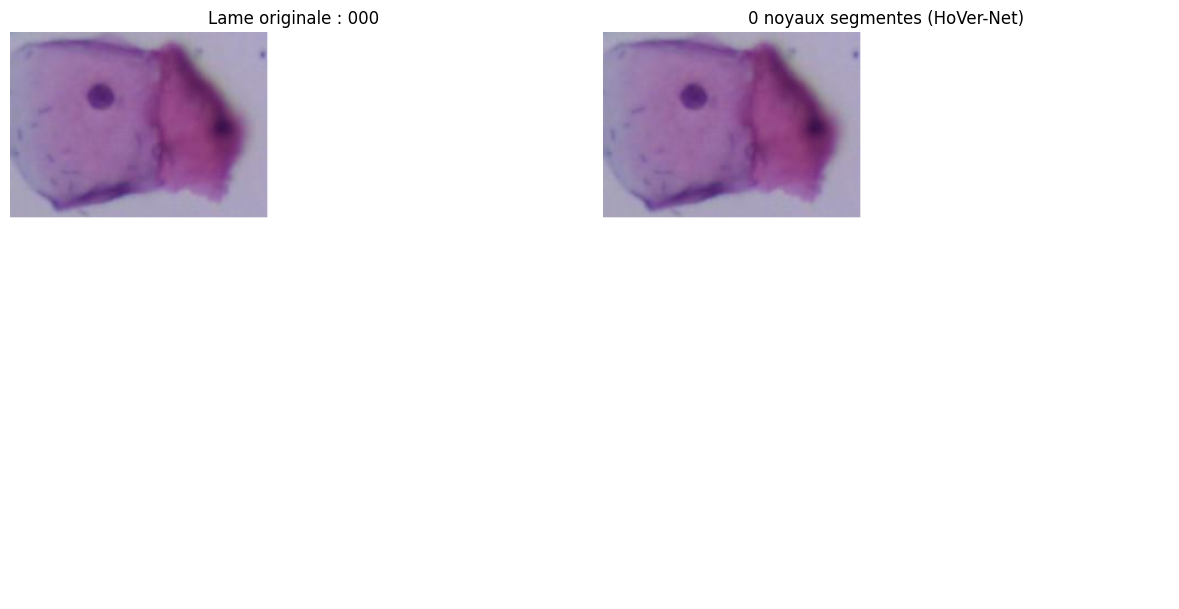

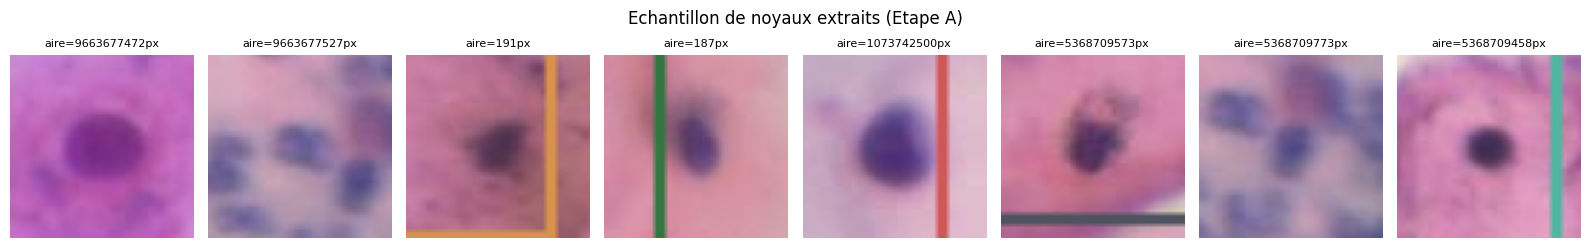

In [29]:
import matplotlib.pyplot as plt

print(f"Lames traitees : {manifest_cx22['slide_id'].nunique()}")
print(f"Noyaux extraits au total : {len(manifest_cx22)}")
print(f"Noyaux par lame (moyenne) : {len(manifest_cx22) / max(1, manifest_cx22['slide_id'].nunique()):.1f}")

# 1) une lame avec son masque d'instances en surimpression
example_slide = manifest_cx22["slide_id"].iloc[0]
example_image_path = Path(CONFIG["paths"]["cx22_images"])
example_matches = list(example_image_path.rglob(f"{example_slide}.*"))
inst_mask = np.load(Path(CONFIG["paths"]["outputs_root"]) / "step_a" / "cx22" / "instance_masks" / f"{example_slide}_instance_mask.npy")

if example_matches:
    base_img = cv2.cvtColor(cv2.imread(str(example_matches[0])), cv2.COLOR_BGR2RGB)
    overlay = base_img.copy()
    for label in np.unique(inst_mask):
        if label == 0:
            continue
        mask = (inst_mask == label).astype(np.uint8)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(overlay, contours, -1, (255, 0, 0), thickness=1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(base_img); axes[0].set_title(f"Lame originale : {example_slide}"); axes[0].axis("off")
    axes[1].imshow(overlay); axes[1].set_title(f"{(inst_mask > 0).sum() and len(np.unique(inst_mask)) - 1} noyaux segmentes (HoVer-Net)"); axes[1].axis("off")
    plt.tight_layout(); plt.show()

# 2) echantillon de crops individuels
sample_crops = manifest_cx22.sample(min(8, len(manifest_cx22)), random_state=0)
fig, axes = plt.subplots(1, len(sample_crops), figsize=(2 * len(sample_crops), 2.5))
if len(sample_crops) == 1:
    axes = [axes]
for ax, (_, row) in zip(axes, sample_crops.iterrows()):
    crop_img = cv2.cvtColor(cv2.imread(row["crop_path"]), cv2.COLOR_BGR2RGB)
    ax.imshow(crop_img); ax.set_title(f"aire={int(row['area_px'])}px", fontsize=8); ax.axis("off")
fig.suptitle("Echantillon de noyaux extraits (Etape A)")
plt.tight_layout(); plt.show()


## 3. Etape B - Classification (EfficientNet-B0) + tete bayesienne (Laplace)

`find_class_directories` / `LabeledCellDataset` cherchent recursivement des dossiers dont le nom
correspond a une cle de `class_folder_map` (insensible a la casse/aux separateurs), puis les font
correspondre a la classe Bethesda associee. Voir `CHANGELOG.md` pour le detail complet du mapping
SIPaKMeD/Herlev -> NILM/LSIL/HSIL/SCC et ses limites (approximation carcinome in situ -> SCC).

**Changement par rapport a la version precedente : `train_one_site` retourne maintenant
l'historique d'entrainement** (`train_losses`, `val_accs` par epoque) au lieu de seulement
l'imprimer, pour permettre de tracer une courbe apres coup (voir cellule de visualisation).


In [31]:
!pip uninstall -y -q laplace laplace-torch curvlinops-for-pytorch
!pip install -q --no-deps "curvlinops-for-pytorch==2.0.1"
!pip install -q --no-deps "laplace-torch==0.2.2.2"

|2026-07-18|15:12:29.869| [WARNING] /usr/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=251) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.4/67.4 kB 887.2 kB/s eta 0:00:000:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 983.7 kB/s eta 0:00:000:00:01


In [81]:
#!pip install -q ivon-opt

|2026-07-18|16:18:20.431| [WARNING] /usr/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=251) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()



In [93]:
import timm
import torch
import torch.nn as nn
from laplace import Laplace
from PIL import Image
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms
from tqdm import tqdm
from sklearn.metrics import recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix


IMAGE_EXTENSIONS = (".png", ".jpg", ".jpeg", ".bmp")


def build_transforms(image_size: int, train: bool) -> transforms.Compose:
    ops = [transforms.Resize((image_size, image_size))]
    if train:
        ops += [transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip(), transforms.RandomRotation(15)]
    ops += [transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])]
    return transforms.Compose(ops)


def _normalize(name: str) -> str:
    return name.strip().lower().replace(" ", "_").replace("-", "_")


def find_class_directories(root: Path, class_folder_map: dict) -> dict:
    """Recherche recursive, insensible a la casse/aux separateurs, des dossiers de classe."""
    normalized_targets = {_normalize(k) for k in class_folder_map}
    found = {}
    for path in root.rglob("*"):
        if path.is_dir() and _normalize(path.name) in normalized_targets:
            found.setdefault(_normalize(path.name), path)
    return found


class LabeledCellDataset(Dataset):
    """Cellules deja labellisees (SIPaKMeD/Herlev) -> (image, label Bethesda)."""

    def __init__(self, root_dir: str, class_folder_map: dict, class_names: list, image_size: int, train: bool):
        self.transform = build_transforms(image_size, train)
        self.samples = []
        root = Path(root_dir)
        class_dirs = find_class_directories(root, class_folder_map)

        for raw_name, bethesda_class in class_folder_map.items():
            class_dir = class_dirs.get(_normalize(raw_name))
            if class_dir is None:
                continue
            label_idx = class_names.index(bethesda_class)
            cropped_subdirs = [d for d in class_dir.rglob("*") if d.is_dir() and "crop" in d.name.lower()]
            for search_root in (cropped_subdirs or [class_dir]):
                for img_path in search_root.rglob("*"):
                    if img_path.suffix.lower() in IMAGE_EXTENSIONS:
                        self.samples.append((img_path, label_idx))

        if not self.samples:
            raise FileNotFoundError(
                f"Aucun echantillon labellise trouve sous {root_dir} pour class_folder_map={list(class_folder_map)}. "
                f"Verifiez la cellule de decouverte /kaggle/input et les noms de dossiers reels."
            )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        return self.transform(Image.open(img_path).convert("RGB")), label


class ManifestCellDataset(Dataset):
    """Lit un manifest.parquet (Etape A) -> (image, row_index). Inference sur Cx22."""

    def __init__(self, manifest_path: str, image_size: int):
        self.manifest = pd.read_parquet(manifest_path)
        self.transform = build_transforms(image_size, train=False)

    def __len__(self):
        return len(self.manifest)

    def __getitem__(self, idx):
        row = self.manifest.iloc[idx]
        return self.transform(Image.open(row["crop_path"]).convert("RGB")), idx


def build_efficientnet_b0(num_classes: int, pretrained: bool = True) -> nn.Module:
    return timm.create_model("efficientnet_b0", pretrained=pretrained, num_classes=num_classes)


class BayesianCellClassifier:
    """Backbone MAP + Last-Layer Laplace Approximation post-hoc (laplace-torch)."""

    def __init__(self, backbone: nn.Module, cfg: dict):
        laplace_cfg = cfg["step_b_classification"]["laplace"]
        self.backbone = backbone
        self.la = Laplace(backbone, likelihood="classification",
                           subset_of_weights=laplace_cfg["subset_of_weights"],
                           hessian_structure=laplace_cfg["hessian_structure"],
                           prior_precision=laplace_cfg["prior_precision"])

    def fit(self, train_loader: DataLoader):
        self.la.fit(train_loader)
        self.la.optimize_prior_precision()

    @torch.no_grad()
    def predict_posterior(self, images: torch.Tensor, n_samples: int = 30) -> dict:
        logits_map = self.backbone(images)
        samples = self.la.predictive_samples(images, n_samples=n_samples)
        return {"logits_map": logits_map, "mu": samples.mean(dim=0), "sigma": samples.std(dim=0)}

    def save(self, path: str):
        torch.save(self.la.state_dict(), path)

    def load(self, path: str):
        self.la.load_state_dict(torch.load(path))


def load_map_backbone(ckpt_path: str, cfg: dict, device: torch.device) -> nn.Module:
    b_cfg = cfg["step_b_classification"]
    checkpoint = torch.load(ckpt_path, map_location=device)
    model = build_efficientnet_b0(b_cfg["num_classes"], pretrained=False).to(device)
    model.load_state_dict(checkpoint["state_dict"])
    model.eval()
    return model


@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, device: torch.device) -> float:
    model.eval()
    correct, total = 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        correct += (model(images).argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    return correct / max(1, total)


@torch.no_grad()
def compute_classification_metrics(model: nn.Module, loader: DataLoader, device: torch.device, class_names: list) -> dict:
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    for images, labels in loader:
        probs = torch.softmax(model(images.to(device)), dim=1).cpu().numpy()
        all_probs.append(probs)
        all_preds.append(probs.argmax(axis=1))
        all_labels.append(labels.numpy())
    y_true, y_pred, y_prob = np.concatenate(all_labels), np.concatenate(all_preds), np.concatenate(all_probs)
    n_classes = len(class_names)
    y_true_onehot = np.eye(n_classes)[y_true]

    metrics = {
        "accuracy": float((y_pred == y_true).mean()),
        "recall_macro": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=list(range(n_classes))),
    }
    try:
        metrics["auc_macro"] = float(roc_auc_score(y_true_onehot, y_prob, average="macro", multi_class="ovr"))
        metrics["auprc_macro"] = float(average_precision_score(y_true_onehot, y_prob, average="macro"))
    except ValueError:
        metrics["auc_macro"], metrics["auprc_macro"] = float("nan"), float("nan")
    return metrics


def train_one_site(site_name: str, images_dir: str, class_folder_map: dict, cfg: dict, device: torch.device) -> dict:
    """MODIFIE : retourne desormais un historique {"train_losses": [...], "val_accs": [...]}
    au lieu de seulement l'imprimer, pour permettre de tracer une courbe apres coup."""
    b_cfg = cfg["step_b_classification"]
    class_names = cfg["classes"]["names"]

    dataset = LabeledCellDataset(images_dir, class_folder_map, class_names, b_cfg["image_size"], train=True)
    val_size = max(1, int(0.15 * len(dataset)))
    train_set, val_set = random_split(dataset, [len(dataset) - val_size, val_size])
    train_loader = DataLoader(train_set, batch_size=b_cfg["batch_size"], shuffle=True, num_workers=2)
    val_loader = DataLoader(val_set, batch_size=b_cfg["batch_size"], shuffle=False, num_workers=2)

    model = build_efficientnet_b0(b_cfg["num_classes"], b_cfg["pretrained"]).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=b_cfg["lr"], weight_decay=b_cfg["weight_decay"])
    criterion = nn.CrossEntropyLoss()

    out_dir = Path(cfg["paths"]["outputs_root"]) / "step_b" / site_name
    out_dir.mkdir(parents=True, exist_ok=True)
    ckpt_path = out_dir / "efficientnet_b0_map.pt"

    history = {"train_losses": [], "val_accs": []}
    best_val_acc = 0.0
    for epoch in range(b_cfg["epochs"]):
        model.train()
        running_loss = 0.0
        for images, labels in tqdm(train_loader, desc=f"[{site_name}] epoch {epoch + 1}/{b_cfg['epochs']}"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        train_loss = running_loss / len(train_set)
        val_acc = evaluate(model, val_loader, device)
        history["train_losses"].append(train_loss)
        history["val_accs"].append(val_acc)
        print(f"[{site_name}] epoch {epoch + 1}: train_loss={train_loss:.4f} val_acc={val_acc:.4f}")
        if val_acc >= best_val_acc:
            best_val_acc = val_acc
            torch.save({"state_dict": model.state_dict(), "class_names": class_names}, ckpt_path)

    print(f"[{site_name}] meilleur val_acc={best_val_acc:.4f} -> {ckpt_path}")

    model.load_state_dict(torch.load(ckpt_path, map_location=device)["state_dict"])
    bayesian_model = BayesianCellClassifier(model, cfg)
    bayesian_model.fit(DataLoader(train_set, batch_size=b_cfg["batch_size"], shuffle=False, num_workers=2))
    laplace_path = out_dir / "laplace_state.pt"
    bayesian_model.save(str(laplace_path))
    print(f"[{site_name}] tete bayesienne (Laplace) ajustee -> {laplace_path}")

    history["best_val_acc"] = best_val_acc
    history["site_name"] = site_name
    return history

### Verification rapide des donnees (avant tout entrainement)

But : detecter immediatement un `class_folder_map` incorrect (0 image trouvee) sans attendre
la fin d'un entrainement complet. Affiche le nombre d'images trouvees par classe Bethesda et
par site.


In [94]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", device)

for site in CONFIG["paths"]["sites"]:
    print(f"\n=== {site['name']} ===")
    try:
        ds = LabeledCellDataset(site["images"], site["class_folder_map"], CONFIG["classes"]["names"],
                                 CONFIG["step_b_classification"]["image_size"], train=False)
        counts = pd.Series([label for _, label in ds.samples]).value_counts().sort_index()
        counts.index = [CONFIG["classes"]["names"][i] for i in counts.index]
        print(counts.to_string())
        print(f"Total : {len(ds.samples)} images")
    except FileNotFoundError as e:
        print("ERREUR :", e)


Device : cuda

=== sipakmed ===
NILM    2411
LSIL     825
HSIL     813
Total : 4049 images

=== herlev ===
NILM     50
LSIL     54
HSIL    102
SCC      45
Total : 251 images


### Execution Etape B

Entraine un classifieur EfficientNet-B0 + tete Laplace, **separement pour chaque site**
(`sipakmed`, `herlev`) — c'est cette independance qui rend la federation de l'Etape C
necessaire/utile.


In [95]:
histories = {}
for site in CONFIG["paths"]["sites"]:
    histories[site["name"]] = train_one_site(
        site["name"], site["images"], site["class_folder_map"], CONFIG, device
    )


|2026-07-18|17:03:53.182| [INFO] Loading pretrained weights from Hugging Face hub (timm/efficientnet_b0.ra_in1k)
|2026-07-18|17:03:53.420| [INFO] HTTP Request: HEAD https://huggingface.co/timm/efficientnet_b0.ra_in1k/resolve/main/model.safetensors "HTTP/1.1 302 Found"
|2026-07-18|17:03:53.422| [INFO] [timm/efficientnet_b0.ra_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
|2026-07-18|17:03:53.444| [INFO] Missing keys (classifier.weight, classifier.bias) discovered while loading pretrained weights. This is expected if model is being adapted.


[sipakmed] epoch 1/15:   0%|          | 0/54 [00:00<?, ?it/s]|2026-07-18|17:03:53.508| [WARNING] /usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=251) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()

[sipakmed] epoch 1/15: 100%|██████████| 54/54 [00:03<00:00, 14.35it/s]


[sipakmed] epoch 1: train_loss=2.5336 val_acc=0.7974


[sipakmed] epoch 2/15: 100%|██████████| 54/54 [00:03<00:00, 14.57it/s]


[sipakmed] epoch 2: train_loss=0.8187 val_acc=0.8863


...

[herlev] epoch 13: train_loss=0.8447 val_acc=0.6757


[herlev] epoch 14/15: 100%|██████████| 4/4 [00:00<00:00,  7.83it/s]


[herlev] epoch 14: train_loss=0.6017 val_acc=0.7027


[herlev] epoch 15/15: 100%|██████████| 4/4 [00:00<00:00,  7.51it/s]


[herlev] epoch 15: train_loss=0.5624 val_acc=0.6486
[herlev] meilleur val_acc=0.7568 -> /kaggle/working/outputs/step_b/herlev/efficientnet_b0_map.pt
[herlev] tete bayesienne (Laplace) ajustee -> /kaggle/working/outputs/step_b/herlev/laplace_state.pt


### Visualisation Etape B

Courbes de perte/accuracy par site, et un batch d'images avec leur prediction (par le modele
MAP, avant tete bayesienne) pour un controle visuel rapide.


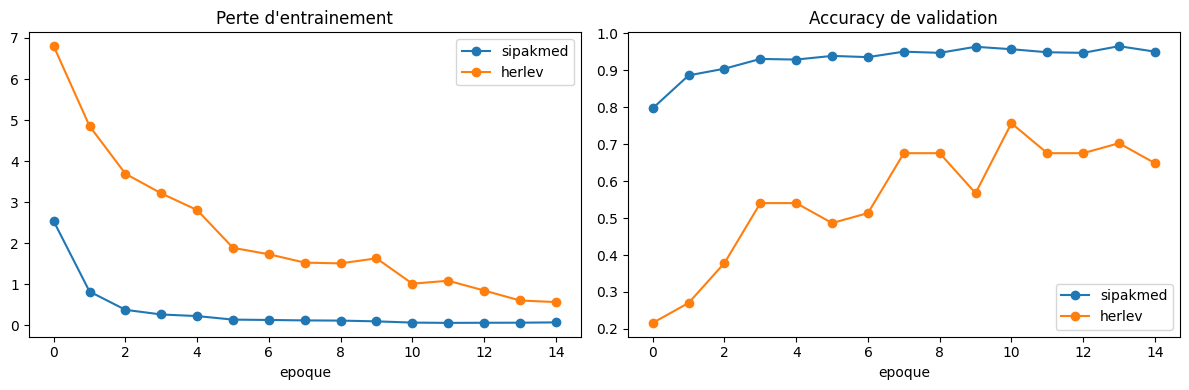

sipakmed : meilleur val_acc = 0.9654
herlev : meilleur val_acc = 0.7568


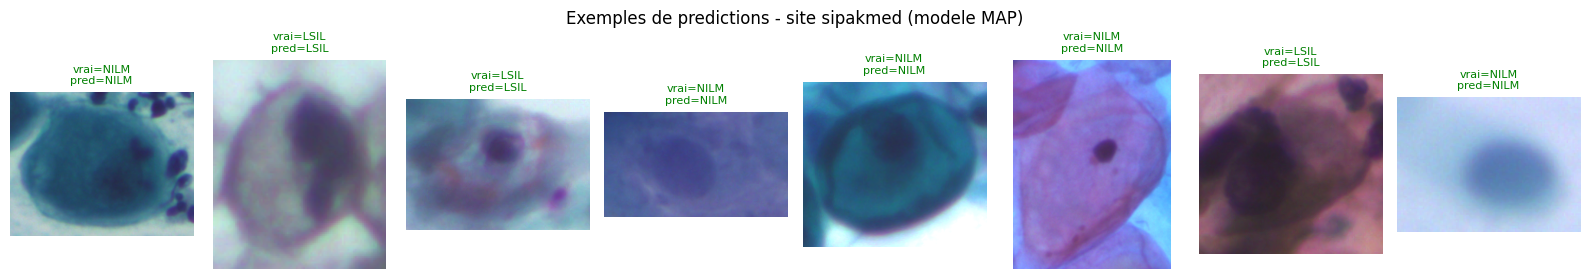

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for site_name, hist in histories.items():
    axes[0].plot(hist["train_losses"], label=site_name, marker="o")
    axes[1].plot(hist["val_accs"], label=site_name, marker="o")
axes[0].set_title("Perte d'entrainement"); axes[0].set_xlabel("epoque"); axes[0].legend()
axes[1].set_title("Accuracy de validation"); axes[1].set_xlabel("epoque"); axes[1].legend()
plt.tight_layout(); plt.show()

for site_name, hist in histories.items():
    print(f"{site_name} : meilleur val_acc = {hist['best_val_acc']:.4f}")

# Batch d'exemples avec prediction du modele MAP (sans la tete bayesienne, pour un apercu rapide)
example_site = CONFIG["paths"]["sites"][0]
model_map = load_map_backbone(
    str(Path(CONFIG["paths"]["outputs_root"]) / "step_b" / example_site["name"] / "efficientnet_b0_map.pt"),
    CONFIG, device,
)
val_ds = LabeledCellDataset(example_site["images"], example_site["class_folder_map"],
                             CONFIG["classes"]["names"], CONFIG["step_b_classification"]["image_size"], train=False)
sample_idx = np.random.choice(len(val_ds), size=min(8, len(val_ds)), replace=False)

fig, axes = plt.subplots(1, len(sample_idx), figsize=(2 * len(sample_idx), 2.8))
if len(sample_idx) == 1:
    axes = [axes]
with torch.no_grad():
    for ax, idx in zip(axes, sample_idx):
        img_tensor, true_label = val_ds[idx]
        pred = model_map(img_tensor.unsqueeze(0).to(device)).argmax(dim=1).item()
        img_path, _ = val_ds.samples[idx]
        disp_img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        ax.imshow(disp_img)
        true_name, pred_name = CONFIG["classes"]["names"][true_label], CONFIG["classes"]["names"][pred]
        color = "green" if pred == true_label else "red"
        ax.set_title(f"vrai={true_name}\npred={pred_name}", fontsize=8, color=color)
        ax.axis("off")
fig.suptitle(f"Exemples de predictions - site {example_site['name']} (modele MAP)")
plt.tight_layout(); plt.show()


## 4. Etape C - Orchestration federee (Flower) : fusion de posterieurs

`num_clients=2` (`sipakmed` + `herlev`). Ce scenario est un non-IID **reel** (pas simule) :
SIPaKMeD n'a aucun exemple SCC, Herlev en a peu. La fusion ponderee par precision est concue
pour ce cas.

**Changement par rapport a la version precedente : `OnlineLaplaceStrategy` garde maintenant un
historique (`self.history`) de `(round, val_loss, val_acc, sigma_moyen_post_fusion)` a chaque
round**, et `run_federated_simulation` retourne aussi la strategie (pas seulement le posterior
final) pour pouvoir tracer la convergence apres coup.


In [97]:
from typing import Dict, List, Optional, Tuple, Union
import ivon
from flwr.common import EvaluateRes, FitRes, Parameters, Scalar, ndarrays_to_parameters, parameters_to_ndarrays
from flwr.server.client_proxy import ClientProxy



def fuse_gaussians_precision_weighted(means: list, variances: list, prior_precision: float) -> tuple:
    """Produit de N gaussiennes N(mu_i, diag(var_i)), avec correction du double
    comptage du prior commun (Bayesian Committee Machine)."""
    n = len(means)
    precisions = [1.0 / v.clamp_min(1e-12) for v in variances]
    summed_precision = (sum(precisions) - (n - 1) * prior_precision).clamp_min(1e-6)
    fused_mean = sum(p * m for p, m in zip(precisions, means)) / summed_precision
    return fused_mean, 1.0 / summed_precision


@torch.no_grad()
def sample_last_layer_predictions(model, images, last_layer_name, mean, variance, n_samples=30) -> dict:
    """Echantillonnage Monte Carlo independant de laplace-torch, a partir du posterior FEDERE."""
    last_layer = dict(model.named_modules())[last_layer_name]
    original_weight, original_bias = last_layer.weight.data.clone(), last_layer.bias.data.clone()
    w_numel = original_weight.numel()
    mean, std = mean.to(images.device), variance.clamp_min(1e-12).sqrt().to(images.device)

    samples = []
    for _ in range(n_samples):
        draw = mean + std * torch.randn_like(mean)
        last_layer.weight.data = draw[:w_numel].view_as(original_weight)
        last_layer.bias.data = draw[w_numel:].view_as(original_bias)
        samples.append(torch.softmax(model(images), dim=1))
    last_layer.weight.data, last_layer.bias.data = original_weight, original_bias

    stacked = torch.stack(samples, dim=0)
    return {"mu": stacked.mean(dim=0), "sigma": stacked.std(dim=0)}


def _is_batchnorm_param(name: str, model: nn.Module) -> bool:
    module = dict(model.named_modules())[name.rsplit(".", 1)[0]]
    return isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d))

def _fedbn_param_names(model: nn.Module) -> list:
    """Tout SAUF BatchNorm : conv + classifieur. FedBN = ce sont les seuls parametres federes."""
    return [n for n, _ in model.named_parameters() if not _is_batchnorm_param(n, model)]

def _flatten_fedbn_params(model: nn.Module) -> torch.Tensor:
    names, params = _fedbn_param_names(model), dict(model.named_parameters())
    return torch.cat([params[n].data.flatten() for n in names])

def _apply_fedbn_params(model: nn.Module, flat: torch.Tensor):
    names, params, offset = _fedbn_param_names(model), dict(model.named_parameters()), 0
    for n in names:
        numel = params[n].numel()
        params[n].data = flat[offset:offset + numel].view_as(params[n]).clone()
        offset += numel


class FlowerLaplaceClient(fl.client.NumPyClient):
    """FedBN : les couches BatchNorm restent toujours locales, jamais envoyees/recues."""

    def __init__(self, site_name, images_dir, class_folder_map, cfg, device):
        self.site_name, self.cfg, self.device = site_name, cfg, device
        b_cfg = cfg["step_b_classification"]
        class_names = cfg["classes"]["names"]
        dataset = LabeledCellDataset(images_dir, class_folder_map, class_names, b_cfg["image_size"], train=True)
        val_size = max(1, int(0.15 * len(dataset)))
        self.train_set, self.val_set = random_split(dataset, [len(dataset) - val_size, val_size])
        ckpt_path = Path(cfg["paths"]["outputs_root"]) / "step_b" / site_name / "efficientnet_b0_map.pt"
        self.model = load_map_backbone(str(ckpt_path), cfg, device)

    def get_parameters(self, config):
        return [_flatten_fedbn_params(self.model).cpu().numpy()]

    def set_parameters(self, parameters):
        _apply_fedbn_params(self.model, torch.tensor(parameters[0], device=self.device, dtype=torch.float32))

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        b_cfg = self.cfg["step_b_classification"]
        train_loader = DataLoader(self.train_set, batch_size=b_cfg["batch_size"], shuffle=True, num_workers=2)
        optimizer = torch.optim.AdamW(self.model.parameters(), lr=b_cfg["lr"], weight_decay=b_cfg["weight_decay"])
        criterion = nn.CrossEntropyLoss()

        self.model.train()
        for _ in range(self.cfg["step_c_federated"]["local_epochs"]):
            for images, labels in train_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                optimizer.zero_grad()
                loss = criterion(self.model(images), labels)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                optimizer.step()

        return [_flatten_fedbn_params(self.model).cpu().numpy()], len(self.train_set), {"site": self.site_name}

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        b_cfg = self.cfg["step_b_classification"]
        class_names = self.cfg["classes"]["names"]
        val_loader = DataLoader(self.val_set, batch_size=b_cfg["batch_size"], shuffle=False, num_workers=2)

        m = compute_classification_metrics(self.model, val_loader, self.device, class_names)
        criterion = nn.CrossEntropyLoss()
        loss_sum, total = 0.0, 0
        self.model.eval()
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                loss_sum += criterion(self.model(images), labels).item() * images.size(0)
                total += labels.size(0)

        metrics_out = {"accuracy": m["accuracy"], "recall_macro": m["recall_macro"], "f1_macro": m["f1_macro"],
                       "auc_macro": m["auc_macro"], "auprc_macro": m["auprc_macro"], "site": self.site_name}
        cm = m["confusion_matrix"]
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                metrics_out[f"cm_{i}_{j}"] = int(cm[i, j])
        return loss_sum / max(1, total), total, metrics_out

class OnlineLaplaceStrategy(fl.server.strategy.FedAvg):
    """FedBN : agregation FedAvg standard (moyenne ponderee par num_examples) restreinte
    aux parametres non-BatchNorm. Plus de fusion gaussienne - poids simples."""

    def __init__(self, class_names: list, **kwargs):
        super().__init__(**kwargs)
        self.class_names = class_names
        self.last_global_params = None
        self.history = []

    def aggregate_fit(self, server_round, results, failures):
        aggregated_parameters, aggregated_metrics = super().aggregate_fit(server_round, results, failures)
        if aggregated_parameters is not None:
            self.last_global_params = parameters_to_ndarrays(aggregated_parameters)[0]
        print(f"[server] round {server_round}: agregation FedBN de {len(results)} clients (conv+classifieur)")
        return aggregated_parameters, aggregated_metrics

    def aggregate_evaluate(self, server_round, results, failures):
        if not results:
            return None, {}
        total = sum(r.num_examples for _, r in results)
        avg_loss = sum(r.loss * r.num_examples for _, r in results) / total
        avg_metrics = {}
        for key in ["accuracy", "recall_macro", "f1_macro", "auc_macro", "auprc_macro"]:
            pairs = [(r.metrics[key], r.num_examples) for _, r in results if not np.isnan(r.metrics[key])]
            avg_metrics[key] = sum(v * w for v, w in pairs) / sum(w for _, w in pairs) if pairs else float("nan")
        n = len(self.class_names)
        summed_cm = np.zeros((n, n), dtype=int)
        for _, r in results:
            for i in range(n):
                for j in range(n):
                    summed_cm[i, j] += r.metrics.get(f"cm_{i}_{j}", 0)
        print(f"[server] round {server_round}: val_loss={avg_loss:.4f} val_acc={avg_metrics['accuracy']:.4f} "
              f"recall={avg_metrics['recall_macro']:.4f} f1={avg_metrics['f1_macro']:.4f}")
        self.history.append({"round": server_round, "val_loss": avg_loss, **avg_metrics, "confusion_matrix": summed_cm})
        return avg_loss, avg_metrics


def make_client_fn(cfg: dict, device: torch.device):
    sites = cfg["paths"]["sites"]

    def client_fn(cid: str) -> fl.client.Client:
        site = sites[int(cid)]
        return FlowerLaplaceClient(site["name"], site["images"], site["class_folder_map"], cfg, device).to_client()

    return client_fn


def run_federated_simulation(cfg: dict, device: torch.device):
    fed_cfg = cfg["step_c_federated"]
    strategy = OnlineLaplaceStrategy(
        class_names=cfg["classes"]["names"],
        fraction_fit=1.0, fraction_evaluate=1.0,
        min_fit_clients=fed_cfg["num_clients"], min_evaluate_clients=fed_cfg["num_clients"],
        min_available_clients=fed_cfg["num_clients"],
    )
    fl.simulation.start_simulation(
        client_fn=make_client_fn(cfg, device), num_clients=fed_cfg["num_clients"],
        config=fl.server.ServerConfig(num_rounds=fed_cfg["num_rounds"]), strategy=strategy,
        client_resources={"num_cpus": 1, "num_gpus": (1.0 / fed_cfg["num_clients"]) if device.type == "cuda" else 0},
    )
    out_path = Path(cfg["paths"]["outputs_root"]) / "step_c" / "global_fedbn_state.pt"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save({"flat_params": strategy.last_global_params}, out_path)
    print(f"Poids globaux FedBN sauvegardes -> {out_path}")
    return strategy


### Execution Etape C

In [98]:
fed_strategy = run_federated_simulation(CONFIG, device)


|2026-07-18|17:06:04.225| [WARNING] /usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

INFO :      Starting Flower simulation, config: num_rounds=10, no round_timeout
2026-07-18 17:06:11,706	INFO worker.py:2012 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:172.19.2.2': 1.0, 'node:__internal_head__': 1.0, 'CPU': 4.0, 'memory': 19855302656.0, 'object_store_memory': 8509415424.0, 'GPU': 2.0, 'accelerator_type:T4': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.5}
INFO :      Flower VCE: Creating VirtualClientEngine

[server] round 1: agregation FedBN de 2 clients (conv+classifieur)


(ClientAppActor pid=8079) /usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=8079) is multi-threaded, use of fork() may lead to deadlocks in the child.
(ClientAppActor pid=8079)   self.pid = os.fork()
(ClientAppActor pid=8081) /usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
(ClientAppActor pid=8081)   warnings.warn(
(ClientAppActor pid=8081) /usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
(ClientAppActor pid=8081)   warnings.warn(
INFO :      aggregate_evaluate: received 2 results and 0 failures
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 2 clients (out of 2)


[server] round 1: val_loss=10.7518 val_acc=0.9441 recall=0.9381 f1=0.9333


INFO :      aggregate_fit: received 2 results and 0 failures
INFO :      configure_evaluate: strategy sampled 2 clients (out of 2)


...

INFO :      aggregate_fit: received 2 results and 0 failures
INFO :      configure_evaluate: strategy sampled 2 clients (out of 2)


[server] round 10: agregation FedBN de 2 clients (conv+classifieur)


(ClientAppActor pid=8081) /usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=8081) is multi-threaded, use of fork() may lead to deadlocks in the child. [repeated 2x across cluster]
(ClientAppActor pid=8081)   self.pid = os.fork() [repeated 2x across cluster]
(ClientAppActor pid=8079) /usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
(ClientAppActor pid=8079)   warnings.warn(
(ClientAppActor pid=8079) /usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
(ClientAppActor pid=8079)   warnings.warn(
INFO :      aggregate_evaluate: received 2 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 10 round(s) in 104.93s
INFO :      	History (loss, distributed):
INFO :      		round 1: 10.75175

[server] round 10: val_loss=40.1834 val_acc=0.9332 recall=0.9379 f1=0.9269
Poids globaux FedBN sauvegardes -> /kaggle/working/outputs/step_c/global_fedbn_state.pt


|2026-07-18|17:08:09.367| [WARNING] /usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



### Visualisation Etape C

Convergence de l'accuracy/perte de validation federee au fil des rounds, et evolution de
l'incertitude moyenne post-fusion (`sigma`) — elle devrait typiquement decroitre a mesure que
les clients s'accordent.


|2026-07-18|17:08:18.903| [WARNING] /usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



,round,val_loss,accuracy,recall_macro,f1_macro,auc_macro,auprc_macro,confusion_matrix
0,1,10.751757,0.944099,0.938090,0.933258,0.569244,0.723946,"[[354, 6, 0, 2], [3, 144, 2, 0], [10, 5, 110, ..."
1,2,12.490498,0.945652,0.951672,0.943798,0.546589,0.726287,"[[360, 7, 0, 0], [5, 122, 1, 0], [14, 0, 125, ..."
2,3,7.506623,0.945652,0.943355,0.939300,0.478056,0.723024,"[[375, 2, 1, 1], [5, 117, 1, 0], [13, 7, 116, ..."
3,4,14.336788,0.899068,0.906592,0.891250,0.556818,0.720489,"[[338, 21, 4, 1], [8, 122, 3, 0], [16, 6, 118,..."
4,5,10.190463,0.888199,0.900528,0.873883,0.614865,0.709697,"[[321, 30, 5, 0], [5, 120, 3, 0], [8, 14, 128,..."
5,6,9.881026,0.922360,0.929443,0.915498,0.470003,0.720366,"[[322, 16, 7, 3], [2, 140, 6, 0], [8, 1, 132, ..."
6,7,31.910052,0.914596,0.926240,0.903517,0.587557,0.723562,"[[330, 28, 3, 1], [6, 133, 2, 0], [11, 0, 126,..."
7,8,19.539484,0.878882,0.903421,0.873226,0.416925,0.709941,"[[321, 46, 3, 1], [5, 122, 1, 1], [8, 4, 123, ..."
8,9,12.053808,0.934783,0.933480,0.921410,0.618669,0.725392,"[[355, 12, 1, 1], [7, 121, 1, 0], [6, 6, 126, ..."
9,10,40.183376,0.933230,0.937873,0.926923,0.466939,0.715099,"[[362, 11, 2, 0], [8, 111, 1, 0], [8, 3, 127, ..."


KeyError: 'sigma_mean'

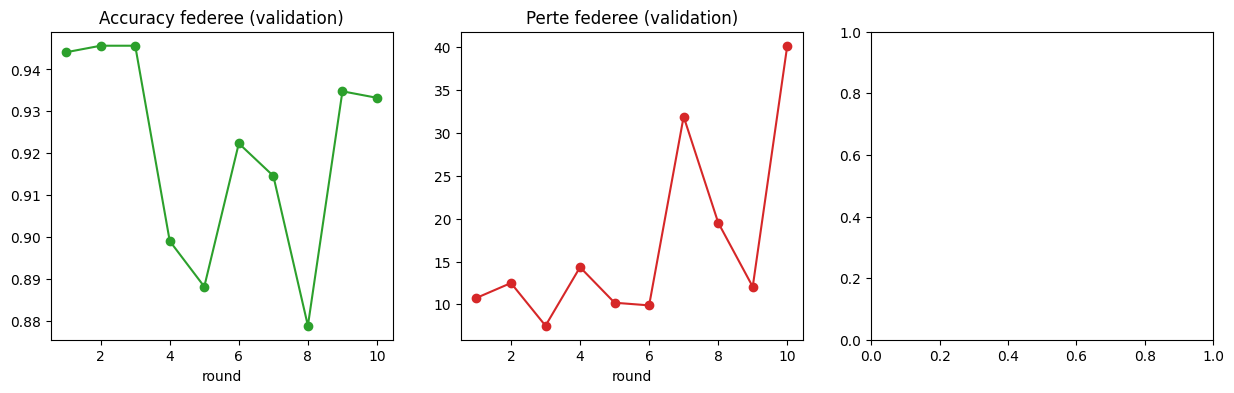

In [99]:
hist_df = pd.DataFrame(fed_strategy.history)
display(hist_df)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(hist_df["round"], hist_df["accuracy"], marker="o", color="tab:green")
axes[0].set_title("Accuracy federee (validation)"); axes[0].set_xlabel("round")
axes[1].plot(hist_df["round"], hist_df["val_loss"], marker="o", color="tab:red")
axes[1].set_title("Perte federee (validation)"); axes[1].set_xlabel("round")
axes[2].plot(hist_df["round"], hist_df["sigma_mean"], marker="o", color="tab:purple")
axes[2].set_title("Incertitude moyenne post-fusion (sigma)"); axes[2].set_xlabel("round")
plt.tight_layout(); plt.show()

print(f"Accuracy federee finale : {hist_df['accuracy'].iloc[-1]:.4f}")
print(f"Sigma moyen final : {hist_df['sigma_mean'].iloc[-1]:.4f}")

best_round = hist_df.loc[hist_df["accuracy"].idxmax()]
print("=== Meilleur round (par accuracy) ===")
print(f"round={int(best_round['round'])}  accuracy={best_round['accuracy']:.4f}  "
      f"recall={best_round['recall_macro']:.4f}  f1={best_round['f1_macro']:.4f}  "
      f"auc={best_round['auc_macro']:.4f}  auprc={best_round['auprc_macro']:.4f}  "
      f"loss={best_round['val_loss']:.4f}  sigma={best_round['sigma_mean']:.4f}")

print("\n=== Dernier round ===")
print(f"round={int(hist_df['round'].iloc[-1])}  accuracy={hist_df['accuracy'].iloc[-1]:.4f}  "
      f"recall={hist_df['recall_macro'].iloc[-1]:.4f}  f1={hist_df['f1_macro'].iloc[-1]:.4f}  "
      f"auc={hist_df['auc_macro'].iloc[-1]:.4f}  auprc={hist_df['auprc_macro'].iloc[-1]:.4f}  "
      f"loss={hist_df['val_loss'].iloc[-1]:.4f}  sigma={hist_df['sigma_mean'].iloc[-1]:.4f}")

## 5. Pont Etape C -> Etape D : appliquer le posterior federe aux cellules de Cx22

Charge le tronc convolutif d'un des deux sites, puis pour chaque cellule du manifest Cx22,
remplace temporairement la derniere couche par des tirages du **posterior FEDERE**
(`global_posterior.pt`).


In [102]:
def apply_fedbn_params_to_new_model(cfg: dict, device: torch.device, flat_params) -> nn.Module:
    base_site = cfg["paths"]["sites"][0]["name"]
    ckpt_path = Path(cfg["paths"]["outputs_root"]) / "step_b" / base_site / "efficientnet_b0_map.pt"
    model = load_map_backbone(str(ckpt_path), cfg, device)
    _apply_fedbn_params(model, torch.tensor(flat_params, device=device, dtype=torch.float32))
    return model


def infer_cx22_with_global_posterior(cfg: dict, device: torch.device) -> pd.DataFrame:
    class_names, b_cfg = cfg["classes"]["names"], cfg["step_b_classification"]
    out_root = Path(cfg["paths"]["outputs_root"])

    global_state = torch.load(out_root / "step_c" / "global_fedbn_state.pt", map_location=device, weights_only=False)

    model = apply_fedbn_params_to_new_model(cfg, device, global_state["flat_params"])

    base_site = cfg["paths"]["sites"][0]
    ref_loader = DataLoader(
        LabeledCellDataset(base_site["images"], base_site["class_folder_map"], class_names, b_cfg["image_size"], train=False),
        batch_size=b_cfg["batch_size"], shuffle=False, num_workers=2,
    )
    bayesian_model = BayesianCellClassifier(model, cfg)
    bayesian_model.fit(ref_loader)

    dataset = ManifestCellDataset(str(out_root / "step_a" / "cx22" / "manifest.parquet"), b_cfg["image_size"])
    loader = DataLoader(dataset, batch_size=b_cfg["batch_size"], shuffle=False, num_workers=2)
    manifest = dataset.manifest.copy()
    for c in class_names:
        manifest[f"mu_{c}"] = 0.0
        manifest[f"sigma_{c}"] = 0.0
    manifest["pred_class"] = ""

    for images, row_indices in loader:
        posterior = bayesian_model.predict_posterior(images.to(device))
        mu, sigma = posterior["mu"].cpu().numpy(), posterior["sigma"].cpu().numpy()
        pred_idx = mu.argmax(axis=1)
        for i, row_idx in enumerate(row_indices.tolist()):
            for c_idx, c in enumerate(class_names):
                manifest.loc[row_idx, f"mu_{c}"] = mu[i, c_idx]
                manifest.loc[row_idx, f"sigma_{c}"] = sigma[i, c_idx]
            manifest.loc[row_idx, "pred_class"] = class_names[pred_idx[i]]

    out_dir = out_root / "step_b" / "cx22"
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / "manifest_with_posteriors.parquet"
    manifest.to_parquet(out_path, index=False)
    print(f"[cx22] posterieurs (FedBN + Laplace local) ecrits -> {out_path}")
    return manifest

### Execution + visualisation du pont

|2026-07-18|17:11:29.477| [WARNING] /usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=251) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()

|2026-07-18|17:11:33.983| [WARNING] /usr/local/lib/python3.12/dist-packages/laplace/baselaplace.py:435: UserWarning: By default `link_approx` is `probit`. Make sure to set it equals to the way you want to call `la(test_data, pred_type=..., link_approx=...)`.
  ):

IOStream.flush timed out
|2026-07-18|17:11:44.195| [WARNING] /usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

|2026-07-18|17:11:34.191| [WARNING] /usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pi

[cx22] posterieurs (FedBN + Laplace local) ecrits -> /kaggle/working/outputs/step_b/cx22/manifest_with_posteriors.parquet
Repartition des cellules Cx22 par classe predite (modele federe) :
pred_class
NILM     7
LSIL    17
HSIL     2
SCC      0


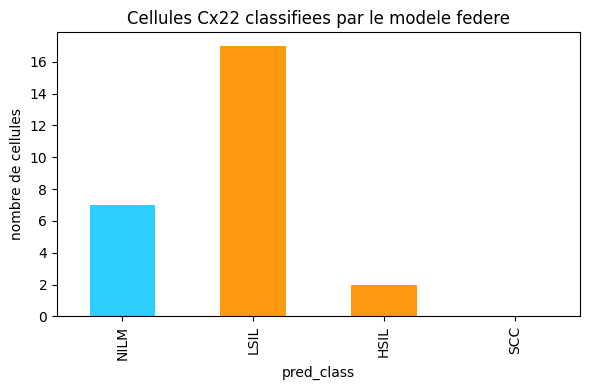

|2026-07-18|17:11:44.835| [WARNING] /usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)




Incertitude (sigma) moyenne par classe predite :
pred_class
NILM    0.232220
LSIL    0.096657
HSIL    0.155051
SCC          NaN


In [103]:
cx22_with_posteriors = infer_cx22_with_global_posterior(CONFIG, device)

class_counts = cx22_with_posteriors["pred_class"].value_counts().reindex(CONFIG["classes"]["names"], fill_value=0)
print("Repartition des cellules Cx22 par classe predite (modele federe) :")
print(class_counts.to_string())

fig, ax = plt.subplots(figsize=(6, 4))
class_counts.plot(kind="bar", ax=ax, color=["#2DCFFF", "#FC990F", "#FC990F", "#DA0126"][: len(class_counts)])
ax.set_title("Cellules Cx22 classifiees par le modele federe")
ax.set_ylabel("nombre de cellules")
plt.tight_layout(); plt.show()

# incertitude moyenne (sigma) par classe predite - sanity check attendu : sigma plus eleve
# sur les classes rares (HSIL/SCC, peu vues par les sites d'entrainement)
sigma_cols = [f"sigma_{c}" for c in CONFIG["classes"]["names"]]
avg_sigma_by_pred = cx22_with_posteriors.groupby("pred_class")[sigma_cols].mean().mean(axis=1)
print("\nIncertitude (sigma) moyenne par classe predite :")
print(avg_sigma_by_pred.reindex(CONFIG["classes"]["names"]).to_string())


## 6. Etape D - Agregation lame complete (MIL par attention, style CLAM)

`build_dataset` pointe sur `outputs/step_b/cx22/manifest_with_posteriors.parquet`. A defaut de
`slide_labels.csv`, `_weak_label` retombe sur la classe la plus severe presente parmi les
cellules de la lame (approximation documentee, pas une verite clinique).

**Changement par rapport a la version precedente : `train_mil` retourne maintenant
l'historique (`losses`, `accs`) pour visualisation.**


In [104]:
class AttentionMIL(nn.Module):
    """Attention-based MIL "gated" (Ilse et al. 2018), brique de base de CLAM."""

    def __init__(self, in_dim, hidden_dim, attention_dim, num_classes, dropout):
        super().__init__()
        self.instance_encoder = nn.Sequential(nn.Linear(in_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout))
        self.attention_V = nn.Sequential(nn.Linear(hidden_dim, attention_dim), nn.Tanh())
        self.attention_U = nn.Sequential(nn.Linear(hidden_dim, attention_dim), nn.Sigmoid())
        self.attention_w = nn.Linear(attention_dim, 1)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, instances: torch.Tensor) -> dict:
        h = self.instance_encoder(instances)
        gated = self.attention_V(h) * self.attention_U(h)
        attention_weights = torch.softmax(self.attention_w(gated).squeeze(-1), dim=0)
        bag_embedding = (attention_weights.unsqueeze(-1) * h).sum(dim=0)
        slide_logits = self.classifier(bag_embedding)
        return {"slide_logits": slide_logits, "slide_probs": torch.softmax(slide_logits, dim=0),
                "attention_weights": attention_weights}


def slide_malignancy_probability(slide_probs: torch.Tensor, class_names: list, benign_class: str = "NILM") -> float:
    return float(1.0 - slide_probs[class_names.index(benign_class)].item())


def _weak_label(cell_rows: pd.DataFrame, class_names: list) -> str:
    severity_rank = {name: i for i, name in enumerate(class_names)}
    most_severe_idx = cell_rows["pred_class"].map(severity_rank).idxmax()
    return cell_rows.loc[most_severe_idx, "pred_class"]


class SlideBagDataset(Dataset):
    """Une lame Cx22 = un bag de cellules. Feature par cellule = [mu..., sigma...]."""

    def __init__(self, manifest_path: str, class_names: list, bag_max_instances: int):
        full = pd.read_parquet(manifest_path)
        self.bags = []
        for slide_id, group in full.groupby("slide_id"):
            if bag_max_instances and len(group) > bag_max_instances:
                group = group.sample(n=bag_max_instances, random_state=0)
            group = group.reset_index(drop=True)
            mu_cols = [f"mu_{c}" for c in class_names]
            sigma_cols = [f"sigma_{c}" for c in class_names]
            features = torch.tensor(group[mu_cols + sigma_cols].values, dtype=torch.float32)
            label_name = _weak_label(group, class_names)
            self.bags.append({"features": features, "label": class_names.index(label_name),
                               "site": "cx22", "slide_id": slide_id, "cell_rows": group})

    def __len__(self):
        return len(self.bags)

    def __getitem__(self, idx):
        return self.bags[idx]


def build_mil_model(cfg: dict, device: torch.device) -> AttentionMIL:
    class_names, d_cfg = cfg["classes"]["names"], cfg["step_d_mil"]
    return AttentionMIL(2 * len(class_names), d_cfg["hidden_dim"], d_cfg["attention_dim"],
                         len(class_names), d_cfg["dropout"]).to(device)


def train_mil(cfg: dict, device: torch.device) -> dict:
    """MODIFIE : retourne l'historique {"losses": [...], "accs": [...]}."""
    class_names, d_cfg = cfg["classes"]["names"], cfg["step_d_mil"]
    manifest_path = Path(cfg["paths"]["outputs_root"]) / "step_b" / "cx22" / "manifest_with_posteriors.parquet"
    dataset = SlideBagDataset(str(manifest_path), class_names, d_cfg["bag_max_instances"])
    loader = DataLoader(dataset, batch_size=1, shuffle=True, collate_fn=lambda batch: batch[0])

    model = build_mil_model(cfg, device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=d_cfg["lr"])
    criterion = nn.CrossEntropyLoss()

    out_dir = Path(cfg["paths"]["outputs_root"]) / "step_d"
    out_dir.mkdir(parents=True, exist_ok=True)

    history = {"losses": [], "accs": []}
    model.train()
    for epoch in range(d_cfg["epochs"]):
        running_loss, correct = 0.0, 0
        for bag in loader:
            label = torch.tensor([bag["label"]], device=device)
            optimizer.zero_grad()
            output = model(bag["features"].to(device))
            loss = criterion(output["slide_logits"].unsqueeze(0), label)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            correct += int(output["slide_logits"].argmax().item() == bag["label"])
        epoch_loss, epoch_acc = running_loss / len(dataset), correct / len(dataset)
        history["losses"].append(epoch_loss)
        history["accs"].append(epoch_acc)
        print(f"epoch {epoch + 1}/{d_cfg['epochs']}: loss={epoch_loss:.4f} acc={epoch_acc:.4f}")

    torch.save({"state_dict": model.state_dict(), "class_names": class_names}, out_dir / "attention_mil.pt")
    print(f"Modele MIL sauvegarde -> {out_dir / 'attention_mil.pt'}")
    return history


@torch.no_grad()
def infer_mil(cfg: dict, device: torch.device) -> pd.DataFrame:
    class_names, d_cfg = cfg["classes"]["names"], cfg["step_d_mil"]
    out_root = Path(cfg["paths"]["outputs_root"])

    model = build_mil_model(cfg, device)
    model.load_state_dict(torch.load(out_root / "step_d" / "attention_mil.pt", map_location=device)["state_dict"])
    model.eval()

    manifest_path = out_root / "step_b" / "cx22" / "manifest_with_posteriors.parquet"
    dataset = SlideBagDataset(str(manifest_path), class_names, d_cfg["bag_max_instances"])
    attention_dir = out_root / "step_d" / "attention_maps"
    attention_dir.mkdir(parents=True, exist_ok=True)

    records = []
    for bag in dataset:
        output = model(bag["features"].to(device))
        cell_rows = bag["cell_rows"].copy()
        cell_rows["attention_weight"] = output["attention_weights"].cpu().numpy()
        cell_rows.to_parquet(attention_dir / f"cx22_{bag['slide_id']}_attention.parquet", index=False)

        slide_probs = output["slide_probs"].cpu().numpy()
        records.append({
            "site": "cx22", "slide_id": bag["slide_id"], "num_cells": len(bag["cell_rows"]),
            **{f"prob_{c}": p for c, p in zip(class_names, slide_probs)},
            "malignancy_prob": slide_malignancy_probability(output["slide_probs"], class_names),
            "pred_class": class_names[int(slide_probs.argmax())],
        })

    result = pd.DataFrame.from_records(records)
    result.to_parquet(out_root / "step_d" / "slide_predictions.parquet", index=False)
    print(f"Predictions au niveau lame -> {out_root / 'step_d' / 'slide_predictions.parquet'}")
    return result


### Execution Etape D

In [105]:
mil_history = train_mil(CONFIG, device)
slide_predictions = infer_mil(CONFIG, device)


|2026-07-18|17:12:07.424| [WARNING] /usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



epoch 1/20: loss=1.3737 acc=0.2500
epoch 2/20: loss=1.3884 acc=0.0833
epoch 3/20: loss=1.3615 acc=0.4167
epoch 4/20: loss=1.3463 acc=0.4167
epoch 5/20: loss=1.3552 acc=0.3333
epoch 6/20: loss=1.3171 acc=0.5833
epoch 7/20: loss=1.2832 acc=0.8333
epoch 8/20: loss=1.2947 acc=0.7500
epoch 9/20: loss=1.2972 acc=0.8333
epoch 10/20: loss=1.2725 acc=0.9167
epoch 11/20: loss=1.2805 acc=0.7500
epoch 12/20: loss=1.2578 acc=0.8333
epoch 13/20: loss=1.2553 acc=0.9167
epoch 14/20: loss=1.2233 acc=0.9167


|2026-07-18|17:12:07.853| [WARNING] /usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



epoch 15/20: loss=1.1945 acc=0.8333
epoch 16/20: loss=1.2134 acc=0.9167
epoch 17/20: loss=1.2184 acc=0.8333
epoch 18/20: loss=1.1733 acc=0.9167
epoch 19/20: loss=1.1662 acc=0.9167
epoch 20/20: loss=1.1486 acc=0.8333
Modele MIL sauvegarde -> /kaggle/working/outputs/step_d/attention_mil.pt


|2026-07-18|17:12:07.880| [WARNING] /usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Predictions au niveau lame -> /kaggle/working/outputs/step_d/slide_predictions.parquet


### Visualisation Etape D

Courbe d'entrainement du MIL, et le resultat final que le pitch promettait depuis le debut :
**une classification par lame complete** (pas juste par cellule), avec sa probabilite calibree.


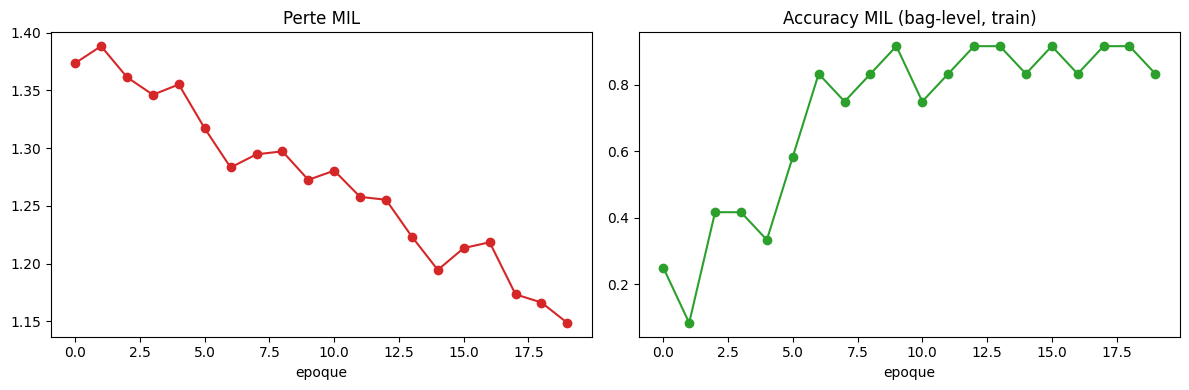

|2026-07-18|17:12:25.906| [WARNING] /usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Predictions par lame :


,slide_id,num_cells,pred_class,malignancy_prob
10,018,1,LSIL,0.783947
5,006,2,LSIL,0.777698
11,019,8,LSIL,0.776735
8,012,2,LSIL,0.776392
3,004,2,LSIL,0.775810
2,003,2,LSIL,0.768411
4,005,2,LSIL,0.759317
7,010,2,LSIL,0.741390
9,015,2,NILM,0.693671
1,001,1,NILM,0.678495


|2026-07-18|17:12:25.918| [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
|2026-07-18|17:12:25.920| [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


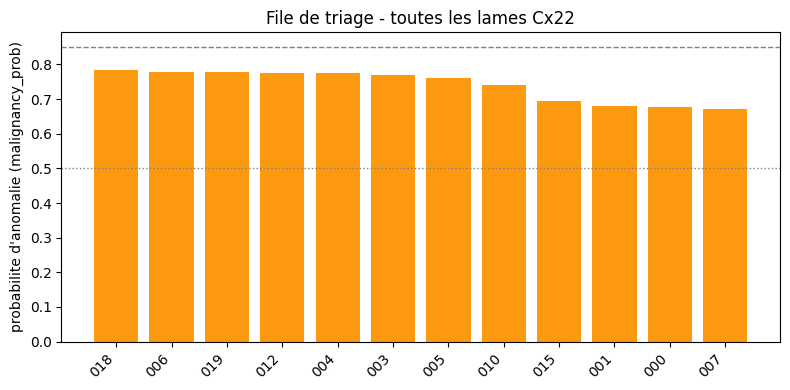

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(mil_history["losses"], marker="o", color="tab:red"); axes[0].set_title("Perte MIL"); axes[0].set_xlabel("epoque")
axes[1].plot(mil_history["accs"], marker="o", color="tab:green"); axes[1].set_title("Accuracy MIL (bag-level, train)"); axes[1].set_xlabel("epoque")
plt.tight_layout(); plt.show()

print("Predictions par lame :")
display(slide_predictions[["slide_id", "num_cells", "pred_class", "malignancy_prob"]].sort_values("malignancy_prob", ascending=False))

fig, ax = plt.subplots(figsize=(8, 4))
ordered = slide_predictions.sort_values("malignancy_prob", ascending=False)
colors = ["#DA0126" if p >= CONFIG["step_f_agent"]["triage_thresholds"]["urgent"]
          else "#FC990F" if p >= CONFIG["step_f_agent"]["triage_thresholds"]["review"]
          else "#2DCFFF" for p in ordered["malignancy_prob"]]
ax.bar(ordered["slide_id"], ordered["malignancy_prob"], color=colors)
ax.axhline(CONFIG["step_f_agent"]["triage_thresholds"]["urgent"], linestyle="--", color="gray", linewidth=1)
ax.axhline(CONFIG["step_f_agent"]["triage_thresholds"]["review"], linestyle=":", color="gray", linewidth=1)
ax.set_ylabel("probabilite d'anomalie (malignancy_prob)")
ax.set_title("File de triage - toutes les lames Cx22")
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()


## 7. Etape E - Explicabilite (segmentation + attention MIL + Grad-CAM)

Trois niveaux d'explication combines : contours de segmentation (Etape A), heatmap d'attention
MIL (Etape D), et Grad-CAM sur les cellules les plus influentes (ce fichier). C'est ici que se
produit le premier visuel "complet" du pipeline — voir `plt.show()` dans `build_explanation`,
deja present dans la version precedente mais jamais atteint car jamais appele.


In [120]:
import json as _json
from matplotlib import gridspec

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget


def compute_gradcam(model, target_layer_name, image_tensor, target_class_idx) -> np.ndarray:
    target_layer = dict(model.named_modules())[target_layer_name]
    with GradCAM(model=model, target_layers=[target_layer]) as cam:
        grayscale_cam = cam(input_tensor=image_tensor, targets=[ClassifierOutputTarget(target_class_idx)])
    return grayscale_cam[0]


def overlay_cam_on_crop(crop_rgb_float01: np.ndarray, cam: np.ndarray) -> np.ndarray:
    return show_cam_on_image(crop_rgb_float01, cam, use_rgb=True, image_weight=0.65)


def find_slide_image(images_dir: Path, slide_id: str) -> Path:
    for ext in (".png", ".jpg", ".jpeg", ".tif", ".tiff"):
        matches = list(images_dir.rglob(f"{slide_id}{ext}"))
        if matches:
            return matches[0]
    raise FileNotFoundError(f"Image de lame introuvable pour {slide_id} dans {images_dir}")


def draw_instance_contours(base_image: np.ndarray, instance_mask: np.ndarray) -> np.ndarray:
    overlay = base_image.copy()
    for label in np.unique(instance_mask):
        if label == 0:
            continue
        mask = (instance_mask == label).astype(np.uint8)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(overlay, contours, -1, (255, 255, 255), thickness=1)
    return overlay


def draw_attention_heatmap(base_image: np.ndarray, cell_rows: pd.DataFrame) -> np.ndarray:
    overlay = base_image.copy()
    weights = cell_rows["attention_weight"].values
    normalized = (weights - weights.min()) / (weights.max() - weights.min() + 1e-8)
    colormap = plt.get_cmap("hot")
    for (_, row), w in zip(cell_rows.iterrows(), normalized):
        color = tuple(int(c * 255) for c in colormap(float(w))[:3])
        radius = 2 + int(6 * w)
        cv2.circle(overlay, (int(row["centroid_x"]), int(row["centroid_y"])), radius, color[::-1], thickness=-1)
    return overlay


def build_explanation(slide_id: str, cfg: dict, device: torch.device) -> dict:
    class_names, e_cfg, b_cfg = cfg["classes"]["names"], cfg["step_e_explainability"], cfg["step_b_classification"]
    out_root = Path(cfg["paths"]["outputs_root"])
    site = "cx22"

    slide_image_path = find_slide_image(Path(cfg["paths"]["cx22_images"]), slide_id)
    base_image = cv2.cvtColor(cv2.imread(str(slide_image_path)), cv2.COLOR_BGR2RGB)
    instance_mask = np.load(out_root / "step_a" / site / "instance_masks" / f"{slide_id}_instance_mask.npy")
    attention_df = pd.read_parquet(out_root / "step_d" / "attention_maps" / f"{site}_{slide_id}_attention.parquet")
    slide_predictions_df = pd.read_parquet(out_root / "step_d" / "slide_predictions.parquet")
    slide_row = slide_predictions_df[slide_predictions_df["slide_id"] == slide_id].iloc[0]

    overlay = draw_instance_contours(base_image, instance_mask)
    overlay = draw_attention_heatmap(overlay, attention_df)

    base_site = cfg["paths"]["sites"][0]["name"]
    model = load_map_backbone(str(out_root / "step_b" / base_site / "efficientnet_b0_map.pt"), cfg, device)
    model.eval()
    transform = build_transforms(b_cfg["image_size"], train=False)

    top_cells = attention_df.sort_values("attention_weight", ascending=False).head(e_cfg["top_k_cells"])
    gradcam_dir = out_root / "step_e" / site / f"{slide_id}_gradcam"
    gradcam_dir.mkdir(parents=True, exist_ok=True)

    top_cells_summary = []
    for _, row in top_cells.iterrows():
        crop = cv2.cvtColor(cv2.imread(row["crop_path"]), cv2.COLOR_BGR2RGB)
        crop_float01 = cv2.resize(crop, (b_cfg["image_size"], b_cfg["image_size"])).astype(np.float32) / 255.0
        image_tensor = transform(Image.fromarray(crop)).unsqueeze(0).to(device)
        target_class_idx = class_names.index(row["pred_class"])
        cam = compute_gradcam(model, e_cfg["gradcam_target_layer"], image_tensor, target_class_idx)
        peak_y, peak_x = np.unravel_index(cam.argmax(), cam.shape)
        center = cam.shape[0] // 2
        print(f"[{row['nucleus_id']}] pic Grad-CAM a ({peak_x},{peak_y}), centre du crop=({center},{center})")
        cam_overlay = overlay_cam_on_crop(crop_float01, cam)
        cam_path = gradcam_dir / f"nucleus{int(row['nucleus_id'])}_gradcam.png"
        cv2.imwrite(str(cam_path), cv2.cvtColor(cam_overlay, cv2.COLOR_RGB2BGR))
        top_cells_summary.append({
            "nucleus_id": int(row["nucleus_id"]), "centroid_x": float(row["centroid_x"]),
            "centroid_y": float(row["centroid_y"]), "pred_class": row["pred_class"],
            "attention_weight": float(row["attention_weight"]),
            "mu": {c: float(row[f"mu_{c}"]) for c in class_names},
            "sigma": {c: float(row[f"sigma_{c}"]) for c in class_names},
            "gradcam_path": str(cam_path),
        })


    fig, axes = plt.subplots(1, 2, figsize=(16, 8), gridspec_kw={"width_ratios": [2, 1]})
    axes[0].imshow(overlay)
    axes[0].set_title(f"cx22 / {slide_id}\npred={slide_row['pred_class']} (P_anormal={slide_row['malignancy_prob']:.2f})")
    axes[0].axis("off")
    axes[1].axis("off")
    if top_cells_summary:
        grid_cols = 3
        grid_rows = int(np.ceil(len(top_cells_summary) / grid_cols))
        inner_grid = gridspec.GridSpecFromSubplotSpec(
            grid_rows, grid_cols, subplot_spec=axes[1].get_subplotspec(), wspace=0.3, hspace=0.4
        )
        for i, cell in enumerate(top_cells_summary):
            ax = fig.add_subplot(inner_grid[i])
            ax.imshow(cv2.cvtColor(cv2.imread(cell["gradcam_path"]), cv2.COLOR_BGR2RGB))
            ax.set_title(f"#{cell['nucleus_id']} a={cell['attention_weight']:.2f}", fontsize=8)
            ax.axis("off")
    fig.tight_layout()

    out_dir = out_root / "step_e" / site
    out_dir.mkdir(parents=True, exist_ok=True)
    fig_path = out_dir / f"{slide_id}_explanation.png"
    fig.savefig(fig_path, dpi=150)
    plt.show()

    summary = {
        "site": site, "slide_id": slide_id, "pred_class": slide_row["pred_class"],
        "malignancy_prob": float(slide_row["malignancy_prob"]),
        "probs": {c: float(slide_row[f"prob_{c}"]) for c in class_names},
        "num_cells": int(slide_row["num_cells"]), "top_cells": top_cells_summary,
        "explanation_image": str(fig_path),
    }
    with open(out_dir / f"{slide_id}_explanation.json", "w", encoding="utf-8") as f:
        _json.dump(summary, f, indent=2, ensure_ascii=False)
    print(f"[cx22/{slide_id}] explication -> {fig_path}")
    return summary


### Execution + visualisation Etape E — **premier test complet sur un exemple**

On choisit la lame la plus urgente de la file de triage (celle avec la plus forte
`malignancy_prob`) comme exemple, pour voir le pipeline a l'oeuvre sur le cas le plus
interessant.


Lame choisie : 019 (8 cellules, pred=LSIL)
Lame choisie pour l'exemple : 019 (pred=LSIL, malignancy_prob=0.78)


|2026-07-18|17:35:44.108| [WARNING] /usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



[1] pic Grad-CAM a (0,0), centre du crop=(32,32)
[4] pic Grad-CAM a (0,0), centre du crop=(32,32)
[7] pic Grad-CAM a (60,43), centre du crop=(32,32)
[5] pic Grad-CAM a (52,60), centre du crop=(32,32)
[0] pic Grad-CAM a (0,36), centre du crop=(32,32)
[3] pic Grad-CAM a (11,0), centre du crop=(32,32)
[6] pic Grad-CAM a (0,36), centre du crop=(32,32)
[2] pic Grad-CAM a (0,12), centre du crop=(32,32)


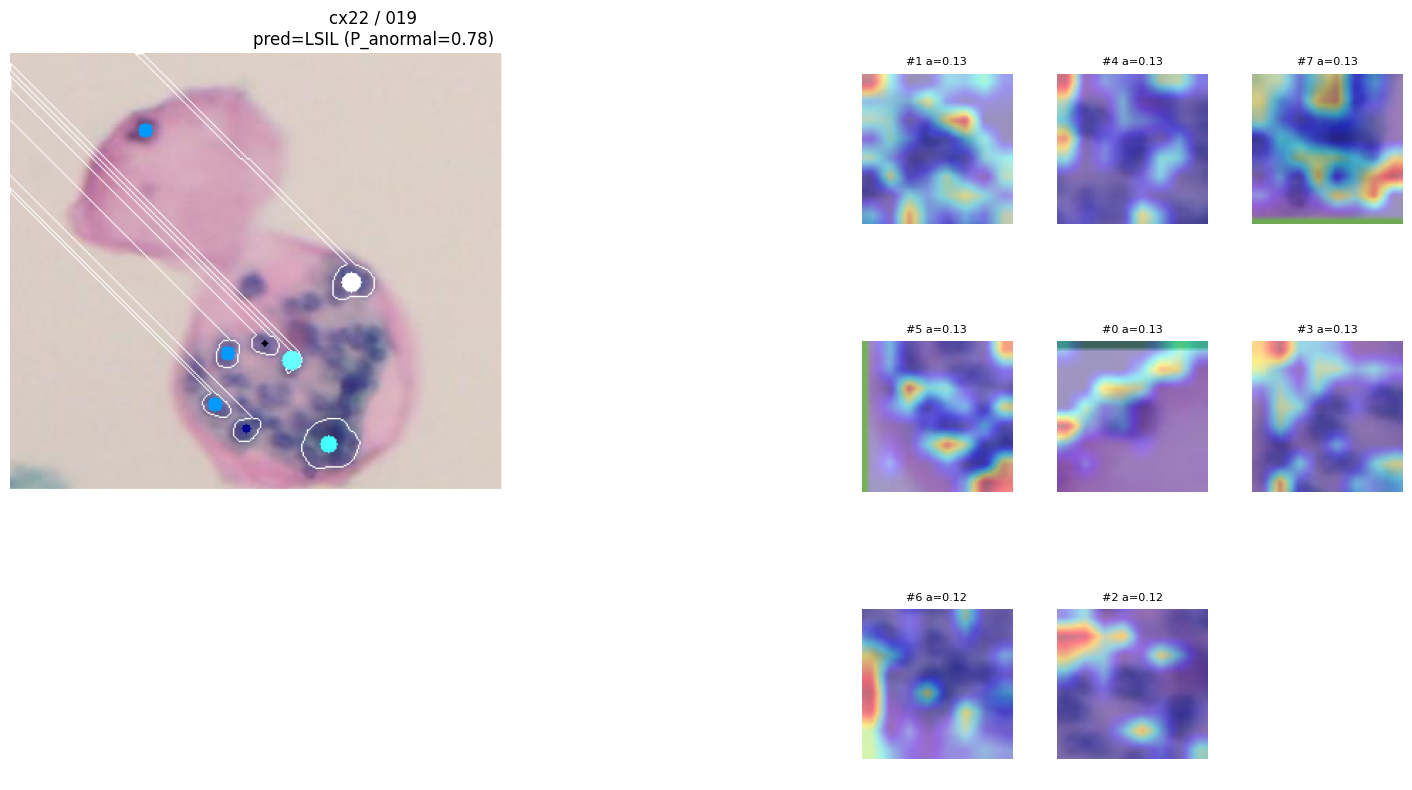

[cx22/019] explication -> /kaggle/working/outputs/step_e/cx22/019_explanation.png


In [121]:
example_slide_row = slide_predictions.sort_values("num_cells", ascending=False).iloc[0]
example_slide_id = example_slide_row["slide_id"]
print(f"Lame choisie : {example_slide_id} ({example_slide_row['num_cells']} cellules, pred={example_slide_row['pred_class']})")
print(f"Lame choisie pour l'exemple : {example_slide_id} "
      f"(pred={example_slide_row['pred_class']}, malignancy_prob={example_slide_row['malignancy_prob']:.2f})")

explanation = build_explanation(example_slide_id, CONFIG, device)


## 8. Etape F - Agent orchestrateur (Llama-3.1-8B-Instruct, local)

**Desactive par defaut** dans cette cellule (`RUN_AGENT = False`) car elle necessite : un
`HF_TOKEN` dans les Secrets Kaggle, l'acceptation de la licence Llama-3.1 sur Hugging Face, et
~5-6 Go de telechargement pour les poids en 4-bit. Passez `RUN_AGENT = True` une fois ces
prerequis en place.

**Pour visualiser ce que l'agent verrait, sans charger le LLM** : la cellule suivante appelle
directement les outils (`get_triage_queue`, `get_slide_summary`) — c'est exactement l'information
que l'agent recevrait avant de formuler sa reponse, utile pour verifier que les donnees sont
correctes avant de brancher le modele de langage.


In [110]:
import re as _re

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig


def load_llama(model_id: str):
    quant_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16)
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModelForCausalLM.from_pretrained(model_id, quantization_config=quant_config, device_map="auto")
    return tokenizer, model


def list_slides(cfg: dict, site: str = None) -> list:
    predictions_path = Path(cfg["paths"]["outputs_root"]) / "step_d" / "slide_predictions.parquet"
    if not predictions_path.exists():
        return []
    df = pd.read_parquet(predictions_path)
    if site:
        df = df[df["site"] == site]
    return df[["site", "slide_id", "pred_class", "malignancy_prob", "num_cells"]].to_dict(orient="records")


def get_triage_queue(cfg: dict) -> list:
    thresholds = cfg["step_f_agent"]["triage_thresholds"]
    slides = list_slides(cfg)

    def priority(p):
        return "urgent" if p >= thresholds["urgent"] else "review" if p >= thresholds["review"] else "routine"

    for slide in slides:
        slide["priority"] = priority(slide["malignancy_prob"])
    return sorted(slides, key=lambda s: s["malignancy_prob"], reverse=True)


def get_slide_summary(cfg: dict, site: str, slide_id: str) -> dict:
    json_path = Path(cfg["paths"]["outputs_root"]) / "step_e" / site / f"{slide_id}_explanation.json"
    if not json_path.exists():
        return {"error": f"Aucune explication trouvee pour {site}/{slide_id}. Lancez l'Etape E d'abord."}
    with open(json_path, "r", encoding="utf-8") as f:
        return _json.load(f)


def get_cell_detail(cfg: dict, site: str, slide_id: str, nucleus_id: int) -> dict:
    summary = get_slide_summary(cfg, site, slide_id)
    if "error" in summary:
        return summary
    for cell in summary["top_cells"]:
        if cell["nucleus_id"] == nucleus_id:
            return cell
    return {"error": f"Cellule {nucleus_id} non trouvee parmi les cellules influentes de {slide_id}."}


TOOL_IMPLEMENTATIONS = {"list_slides": list_slides, "get_triage_queue": get_triage_queue,
                         "get_slide_summary": get_slide_summary, "get_cell_detail": get_cell_detail}

TOOLS_DESCRIPTION = """Outils disponibles (arguments entre parentheses) :
- list_slides(site: str optionnel) : liste les lames avec classe predite et probabilite d'anomalie.
- get_triage_queue() : file de triage triee par urgence (priorite urgent/review/routine).
- get_slide_summary(site: str, slide_id: str) : details complets d'une lame.
- get_cell_detail(site: str, slide_id: str, nucleus_id: int) : detail d'une cellule.

Pour appeler un outil, reponds UNIQUEMENT avec un objet JSON {"tool": "...", "arguments": {...}}.
Sinon, reponds normalement en texte."""

SYSTEM_PROMPT = f"""Tu es un assistant de triage pour un pipeline de depistage cytologique cervical (screening, pas diagnostic definitif).

Regles strictes :
- N'affirme JAMAIS un resultat que les outils ne renvoient pas explicitement.
- Cite systematiquement les elements concrets (classe predite, malignancy_prob, sigma).
- Rappelle que ce pipeline est une AIDE au triage, pas un diagnostic.
- Si une information manque, dis-le explicitement.

{TOOLS_DESCRIPTION}
"""


class PathologyTriageAgent:
    def __init__(self, cfg: dict, tokenizer, model):
        self.cfg, self.tokenizer, self.model = cfg, tokenizer, model
        self.messages = [{"role": "system", "content": SYSTEM_PROMPT}]

    def _generate(self) -> str:
        prompt = self.tokenizer.apply_chat_template(self.messages, tokenize=False, add_generation_prompt=True)
        inputs = self.tokenizer(prompt, return_tensors="pt").to(self.model.device)
        output_ids = self.model.generate(**inputs, max_new_tokens=512, do_sample=False,
                                          pad_token_id=self.tokenizer.eos_token_id)
        new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
        return self.tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

    def _try_parse_tool_call(self, text: str):
        match = _re.search(r"\{.*\}", text, _re.DOTALL)
        if not match:
            return None
        try:
            payload = _json.loads(match.group(0))
        except _json.JSONDecodeError:
            return None
        return payload if "tool" in payload else None

    def chat(self, user_message: str, max_tool_calls: int = 5) -> str:
        self.messages.append({"role": "user", "content": user_message})
        for _ in range(max_tool_calls):
            reply = self._generate()
            tool_call = self._try_parse_tool_call(reply)
            if tool_call is None:
                self.messages.append({"role": "assistant", "content": reply})
                return reply
            result = TOOL_IMPLEMENTATIONS[tool_call["tool"]](self.cfg, **tool_call.get("arguments", {}))
            self.messages.append({"role": "assistant", "content": reply})
            self.messages.append({
                "role": "user",
                "content": f"Resultat de l'outil {tool_call['tool']} : {_json.dumps(result, ensure_ascii=False, default=str)}",
            })
        return "Nombre maximal d'appels d'outils atteint sans reponse finale."


RUN_AGENT = False  # passer a True si HF_TOKEN configure + licence Llama-3.1 acceptee

if RUN_AGENT:
    tokenizer, llama_model = load_llama(CONFIG["step_f_agent"]["llm_model"])
    agent = PathologyTriageAgent(CONFIG, tokenizer, llama_model)
    print(agent.chat("Quelles sont les lames les plus urgentes a revoir ?"))
else:
    print("RUN_AGENT=False : LLM non charge. Voir la cellule suivante pour un apercu des donnees")
    print("que l'agent recevrait (sans le modele de langage).")


RUN_AGENT=False : LLM non charge. Voir la cellule suivante pour un apercu des donnees
que l'agent recevrait (sans le modele de langage).


### Apercu des donnees de l'agent (sans charger le LLM)

In [122]:
queue = get_triage_queue(CONFIG)
print("File de triage complete :")
for item in queue:
    print(f"  [{item['priority'].upper():7s}] {item['site']}/{item['slide_id']} - "
          f"{item['pred_class']} ({item['malignancy_prob']:.0%}, {item['num_cells']} cellules)")

print(f"\nDetail complet que l'agent recevrait pour la lame la plus urgente ({queue[0]['slide_id']}) :")
top_summary = get_slide_summary(CONFIG, queue[0]["site"], queue[0]["slide_id"])
print(_json.dumps({k: v for k, v in top_summary.items() if k != "top_cells"}, indent=2, ensure_ascii=False))
print(f"... + {len(top_summary['top_cells'])} cellules influentes detaillees (mu/sigma/attention/Grad-CAM)")


|2026-07-18|17:36:49.968| [WARNING] /usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



File de triage complete :
  [REVIEW ] cx22/018 - LSIL (78%, 1 cellules)
  [REVIEW ] cx22/006 - LSIL (78%, 2 cellules)
  [REVIEW ] cx22/019 - LSIL (78%, 8 cellules)
  [REVIEW ] cx22/012 - LSIL (78%, 2 cellules)
  [REVIEW ] cx22/004 - LSIL (78%, 2 cellules)
  [REVIEW ] cx22/003 - LSIL (77%, 2 cellules)
  [REVIEW ] cx22/005 - LSIL (76%, 2 cellules)
  [REVIEW ] cx22/010 - LSIL (74%, 2 cellules)
  [REVIEW ] cx22/015 - NILM (69%, 2 cellules)
  [REVIEW ] cx22/001 - NILM (68%, 1 cellules)
  [REVIEW ] cx22/000 - NILM (68%, 1 cellules)
  [REVIEW ] cx22/007 - NILM (67%, 1 cellules)

Detail complet que l'agent recevrait pour la lame la plus urgente (018) :
{
  "site": "cx22",
  "slide_id": "018",
  "pred_class": "LSIL",
  "malignancy_prob": 0.7839473932981491,
  "probs": {
    "NILM": 0.2160526067018509,
    "LSIL": 0.3409159481525421,
    "HSIL": 0.24269047379493713,
    "SCC": 0.20034101605415344
  },
  "num_cells": 1,
  "explanation_image": "/kaggle/working/outputs/step_e/cx22/018_explanation.p

## 9. Recapitulatif de l'exemple traite de bout en bout

Resume final, cellule par cellule, du chemin complet parcouru par la lame choisie
(la plus urgente de la file de triage), de l'image brute a la decision de triage — c'est la
reponse concrete a "je veux tester un exemple et voir ses resultats".


In [112]:
print("=" * 70)
print(f"RESUME — {explanation['site']}/{explanation['slide_id']}")
print("=" * 70)
print(f"Classe predite        : {explanation['pred_class']}")
print(f"Probabilite d'anomalie : {explanation['malignancy_prob']:.1%}")
print(f"Nombre de cellules     : {explanation['num_cells']}")
print("\nProbabilites par classe (niveau lame) :")
for c, p in explanation["probs"].items():
    bar = "#" * int(p * 40)
    print(f"  {c:6s} {p:6.1%} {bar}")

print(f"\nTop {len(explanation['top_cells'])} cellules les plus influentes (attention MIL) :")
top_cells_df = pd.DataFrame(explanation["top_cells"])[["nucleus_id", "pred_class", "attention_weight"]]
display(top_cells_df.sort_values("attention_weight", ascending=False))

thresholds = CONFIG["step_f_agent"]["triage_thresholds"]
priority = ("URGENT" if explanation["malignancy_prob"] >= thresholds["urgent"]
            else "REVIEW" if explanation["malignancy_prob"] >= thresholds["review"] else "ROUTINE")
print(f"\n>>> Priorite de triage assignee : {priority}")
print(f">>> Image d'explication complete : {explanation['explanation_image']}")


|2026-07-18|17:14:02.783| [WARNING] /usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



RESUME — cx22/018
Classe predite        : LSIL
Probabilite d'anomalie : 78.4%
Nombre de cellules     : 1

Probabilites par classe (niveau lame) :
  NILM    21.6% ########
  LSIL    34.1% #############
  HSIL    24.3% #########
  SCC     20.0% ########

Top 1 cellules les plus influentes (attention MIL) :


,nucleus_id,pred_class,attention_weight
0,0,LSIL,1.0



>>> Priorite de triage assignee : REVIEW
>>> Image d'explication complete : /kaggle/working/outputs/step_e/cx22/018_explanation.png


## Recapitulatif : ordre d'execution

1. Installation + redemarrage du kernel.
2. Verification de l'environnement (patch numpy + imports).
3. Configuration + decouverte des chemins Kaggle.
4. **Etape A** (executee) : segmentation Cx22 + visualisation.
5. **Etape B** (executee) : entrainement sipakmed + herlev + courbes + exemples.
6. **Etape C** (executee) : simulation federee + courbe de convergence.
7. **Pont C -> D** (execute) : posterior federe applique a Cx22 + repartition par classe.
8. **Etape D** (executee) : MIL + file de triage visualisee.
9. **Etape E** (executee) : explication complete sur la lame la plus urgente.
10. **Etape F** : donnees de l'agent visualisees ; LLM optionnel (`RUN_AGENT = True`).
11. Recapitulatif final de l'exemple traite.

Chaque etape ecrit ses sorties sous `/kaggle/working/outputs/` (persistant dans la session, a
telecharger via **Output** en fin de run). Voir `CHANGELOG.md` pour le detail complet de ce qui
differe entre cette version et la version generique `pipeline.ipynb`.
